# 02 · Attempt Propensity π(X)

**Purpose:** Generate rolling-origin out-of-fold estimates for the probability of attempting a field goal using a multinomial model over actions (FG, punt, go_for_it).

**Inputs:** Reference/pbp_head.csv, Reference/fg_attempts_sample.csv

**Outputs:**
- reports/attempt_pi/attempt_pi_oof_predictions.csv (includes p_hat_multinom, weight_multinom, action_actual, action_pred)
- reports/attempt_pi/attempt_pi_metrics_by_season.csv
- reports/attempt_pi/attempt_pi_calibration.csv
- reports/attempt_pi/fg_rates_by_season_long.csv, reports/attempt_pi/fg_rates_by_season_wide.csv
- reports/attempt_pi/attempt_pi_weight_stats.csv, reports/attempt_pi/attempt_pi_weight_extremes.csv (plus per-action variants)

**Sections:**
- [Parameters & Modes](#parameters--modes)
- [Imports](#imports--install-if-missing)
- [Utilities & Helpers](#utilities--helpers)
- [Data Load & Peek](#data-load--peek)
- [Stage Logic](#stage-logic)
- [Artifacts](#artifacts)
- [Session Info](#session-info)


In [8]:
# Parameters & Modes
# Set PROJECT_ROOT to the current working directory with the last path segment removed
PROJECT_ROOT <- sub("[/\\\\][^/\\\\]*$", "", getwd())

reference_dir <- file.path(PROJECT_ROOT, 'Reference')
pbp_data_dir <- 'G:\\Python\\Data\\NFL'
data_dir <- file.path(PROJECT_ROOT, 'data')
leverage_dir <- file.path(PROJECT_ROOT,'data','leverage')
reports_dir <- file.path(PROJECT_ROOT, 'reports')
config_path <- file.path(PROJECT_ROOT, 'config', 'params.yaml')

SEASONS <- 2015:2024

default_params <- list(
  time_knots = c(60, 120, 300),
  late_flags = c(120, 60),
  p_clip_min = 0.05,
  p_clip_max = 0.98,
  kickable_cap_modeling = 65,
  kickable_cap_audit = 50,
  tau_grid = c(0.03, 0.05, 0.07, 0.10),
  df_distance = 5,
  df_yardline = 5,
  df_yards_to_go = 5
)

params <- default_params

if (file.exists(config_path)) {
  tryCatch({
    config_values <- yaml::read_yaml(config_path)
    params <- utils::modifyList(params, config_values, keep.null = TRUE)
  }, error = function(e) message('Config read failed, using defaults: ', e$message))
}

print(PROJECT_ROOT)
print(data_dir)
set.seed(20240517)

[1] "g:/Other computers/Desktop/My Files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model"
[1] "g:/Other computers/Desktop/My Files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model/data"


In [9]:

# Imports — install if missing

dependencies <- c(
  'dplyr', 'tibble', 'tidyr', 'readr', 'stringr', 'purrr', 'ggplot2','zoo',
  'splines', 'splines2', 'pROC', 'yaml', 'rlang', 'nnet','patchwork','gganimate','transformr','gifski'
)

installed <- rownames(installed.packages())

for (pkg in dependencies) {
  if (!pkg %in% installed) {
    install.packages(pkg)
  }
  suppressPackageStartupMessages(library(pkg, character.only = TRUE))
}


### Function Index

- `get_schema()` — quick schema preview of a data frame.
- `add_time_features()` — derive common time and score features.
- `clip_probabilities()` — constrain probabilities to [min, max].
- `stabilized_ipw()` — compute stabilized inverse-probability weights per fold.
- `effective_sample_size()` — calculate ESS from weights.
- `calibration_summary()` — summarize calibration by bins.
- `plot_calibration()` — simple calibration scatter + smoother.


In [10]:
# Utilities & Helpers (≤40 lines each)
get_schema <- function(df, n = 5) {
  tibble::tibble(
    name = names(df),
    class = purrr::map_chr(df, ~ paste(class(.x), collapse = '/')),
    sample = purrr::map_chr(df, ~ paste(head(.x, n), collapse = ', '))
  )
}


ensure_columns <- function(df, defaults) {
  for (col in names(defaults)) {
    if (!col %in% names(df)) {
      df[[col]] <- defaults[[col]]
    }
  }
  df
}

brier <- function(y, p) {
  mean((y - p)^2, na.rm = TRUE)
}

logloss <- function(y, p, eps = 1e-8) {
  p <- pmin(pmax(p, eps), 1 - eps)
  -mean(y * log(p) + (1 - y) * log(1 - p), na.rm = TRUE)
}

clip_probabilities <- function(x, lower = 0.05, upper = 0.98) {
  pmin(pmax(x, lower), upper)
}

# Manual distance B-splines with fixed knots and boundaries
build_distance_bs <- function(x, knots = c(25,35,45,55), degree = 3, bknots = c(15,70)) {
  stopifnot(is.numeric(x))
  bs <- splines2::bSpline(x, knots = knots, degree = degree, intercept = FALSE, Boundary.knots = bknots)
  colnames(bs) <- paste0('dist_bs_', seq_len(ncol(bs)))
  as.data.frame(bs)
}


add_time_features <- function(df) {
  df %>%
    dplyr::mutate(
      time_remaining = dplyr::coalesce(game_seconds_remaining, 0),
      log_time_remaining = log1p(pmax(time_remaining, 0)),
      late_game_bucket = dplyr::case_when(
        time_remaining <= late_flags[2] ~ 'inside_1_minute',
        time_remaining <= late_flags[1] ~ 'two_minutes',
        TRUE ~ 'early'
      ),
      distance_bucket = cut(field_goal_distance, breaks = c(0, 30, 40, 50, 60, Inf), right = FALSE),
      wind_bucket = cut(weather_wind_mph, breaks = c(-Inf, 5, 10, 15, 25, Inf), right = FALSE)
    )
}

clip_probabilities <- function(x, lower = 0.02, upper = 0.98) {
  pmin(pmax(x, lower), upper)
}

# Stabilized IPW helper for binary treatment y in [0,1] given p_hat and a target prevalence
stabilized_ipw <- function(y, p_hat, target, clip = c(0.02, 0.98)) {
  p_hat <- clip_probabilities(p_hat, clip[1], clip[2])
  w <- ifelse(
    y == 1L,
    target / p_hat,
    (1 - target) / (1 - p_hat)
  )
  # cap weights between clip[1] and 1/clip[1]
  pmin(pmax(w, clip[1]), 1/clip[1])
}

effective_sample_size <- function(weights) {
  if (length(weights) == 0 || all(is.na(weights))) {
    return(NA_real_)
  }
  w <- weights[is.finite(weights)]
  if (length(w) == 0) {
    return(NA_real_)
  }
  sum_w <- sum(w)
  sum_sq <- sum(w^2)
  if (sum_sq == 0) {
    return(NA_real_)
  }
  sum_w^2 / sum_sq
}

calibration_summary <- function(df, truth_col, estimate_col, weight_col = NULL, by = NULL, bins = 5) {
  if (!is.null(by) && length(by) > 0) {
    df <- df %>%
      dplyr::mutate(dplyr::across(dplyr::all_of(by), as.factor))
  }
  if (!('calibration_bin' %in% names(df))) {
    df <- df %>%
      dplyr::mutate(calibration_bin = cut(.data[[estimate_col]], breaks = bins, include.lowest = TRUE))
  }
  df %>%
    dplyr::group_by(dplyr::across(dplyr::all_of(c(by, 'calibration_bin')))) %>%
    dplyr::summarise(
      truth = mean(.data[[truth_col]], na.rm = TRUE),
      estimate = mean(.data[[estimate_col]], na.rm = TRUE),
      weight = if (is.null(weight_col)) dplyr::n() else sum(.data[[weight_col]], na.rm = TRUE),
      .groups = 'drop'
    )
}

plot_calibration <- function(df, truth_col = 'truth', estimate_col = 'estimate') {
  ggplot2::ggplot(df, ggplot2::aes(x = .data[[estimate_col]], y = .data[[truth_col]])) +
    ggplot2::geom_point() +
    ggplot2::geom_abline(slope = 1, intercept = 0, linetype = 'dashed', colour = 'grey50') +
    ggplot2::labs(x = 'Estimated', y = 'Observed', title = 'Calibration Plot')
}




- Source: `data/fg_all.csv` produced by `01_data_prep.ipynb`
- Scope: 4th-down decision set already prepared in fg_all; we further subset to field_goal vs pass/run and drop PATs and >70 yd implied kicks.

In [11]:
# Stage Logic — Attempt Propensity

# Build decision frame from fg_all
fg_path <- file.path(data_dir, 'fg_all.csv')
stopifnot(file.exists(fg_path))

fg_all <- readr::read_csv(fg_path, show_col_types = FALSE)

# Filter to relevant actions: include punts as part of the not_FG class, drop PATs
# Note: plays already limited to 4th downs upstream. All rows must have a derived kick_distance
decision <- fg_all %>%
  dplyr::filter(is_pat == 0L) %>%
  # include punts; assume kick_distance is already derived for punts
  dplyr::filter(play_type_original %in% c('field_goal','pass','run','punt')) %>%
  dplyr::filter(!is.na(kick_distance)) %>%
  dplyr::filter(kick_distance <= 70) %>%
  dplyr::mutate(
    attempt_fg = as.integer(play_type_original == 'field_goal'),
    action = dplyr::case_when(
      play_type_original == 'field_goal' ~ 'FG',
      play_type_original == 'punt' ~ 'punt',
      TRUE ~ 'go_for_it'
    ),
    # score flags (no splines for score)
    go_ahead      = as.integer(!is.na(score_differential) & score_differential >= -2 & score_differential <= 0),
    one_score_down= as.integer(!is.na(score_differential) & score_differential <= -4 & score_differential >= -8),
    to_tie        = as.integer(score_differential == -3),
    extend_lead   = as.integer(!is.na(score_differential) & score_differential >= 1),
    two_score_down= as.integer(!is.na(score_differential) & score_differential <= -9 & score_differential >= -11),

    # weather z-scores already in fg_all as wind_z/temp_z; fall back if missing
    wind_z = if ('wind_z' %in% names(.)) wind_z else NA_real_,
    temp_z = if ('temp_z' %in% names(.)) temp_z else NA_real_,
    # stadium simple features from data prep
    indoors = dplyr::coalesce(as.integer(indoors), 0L),
    is_turf = dplyr::coalesce(as.integer(is_turf), 0L),
    high_altitude = dplyr::coalesce(as.integer(high_altitude), 0L)
  ) %>%
  dplyr::filter(!is.na(game_seconds_remaining))

print(head(decision))

# A tibble: 6 × 97
  game_id play_id old_game_id season  week season_type playoffs   qtr game_date 
  <chr>     <dbl>       <dbl>  <dbl> <dbl> <chr>          <dbl> <dbl> <date>    
1 2012_0…     588  2012090908   2012     1 REG                0     1 2012-09-09
2 2012_0…     727  2012090908   2012     1 REG                0     1 2012-09-09
3 2012_0…    1748  2012090908   2012     1 REG                0     2 2012-09-09
4 2012_0…    2064  2012090908   2012     1 REG                0     3 2012-09-09
5 2012_0…    2665  2012090908   2012     1 REG                0     4 2012-09-09
6 2012_0…    2857  2012090908   2012     1 REG                0     4 2012-09-09
# ℹ 88 more variables: home_team <chr>, away_team <chr>, posteam <chr>,
#   defteam <chr>, game_seconds_remaining <dbl>,
#   quarter_seconds_remaining <dbl>, score_differential <dbl>,
#   yardline_100 <dbl>, ydstogo <dbl>, wp <dbl>, wpa <dbl>, epa <dbl>,
#   posteam_timeouts_remaining <dbl>, defteam_timeouts_remaining <dbl>,
#   go

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


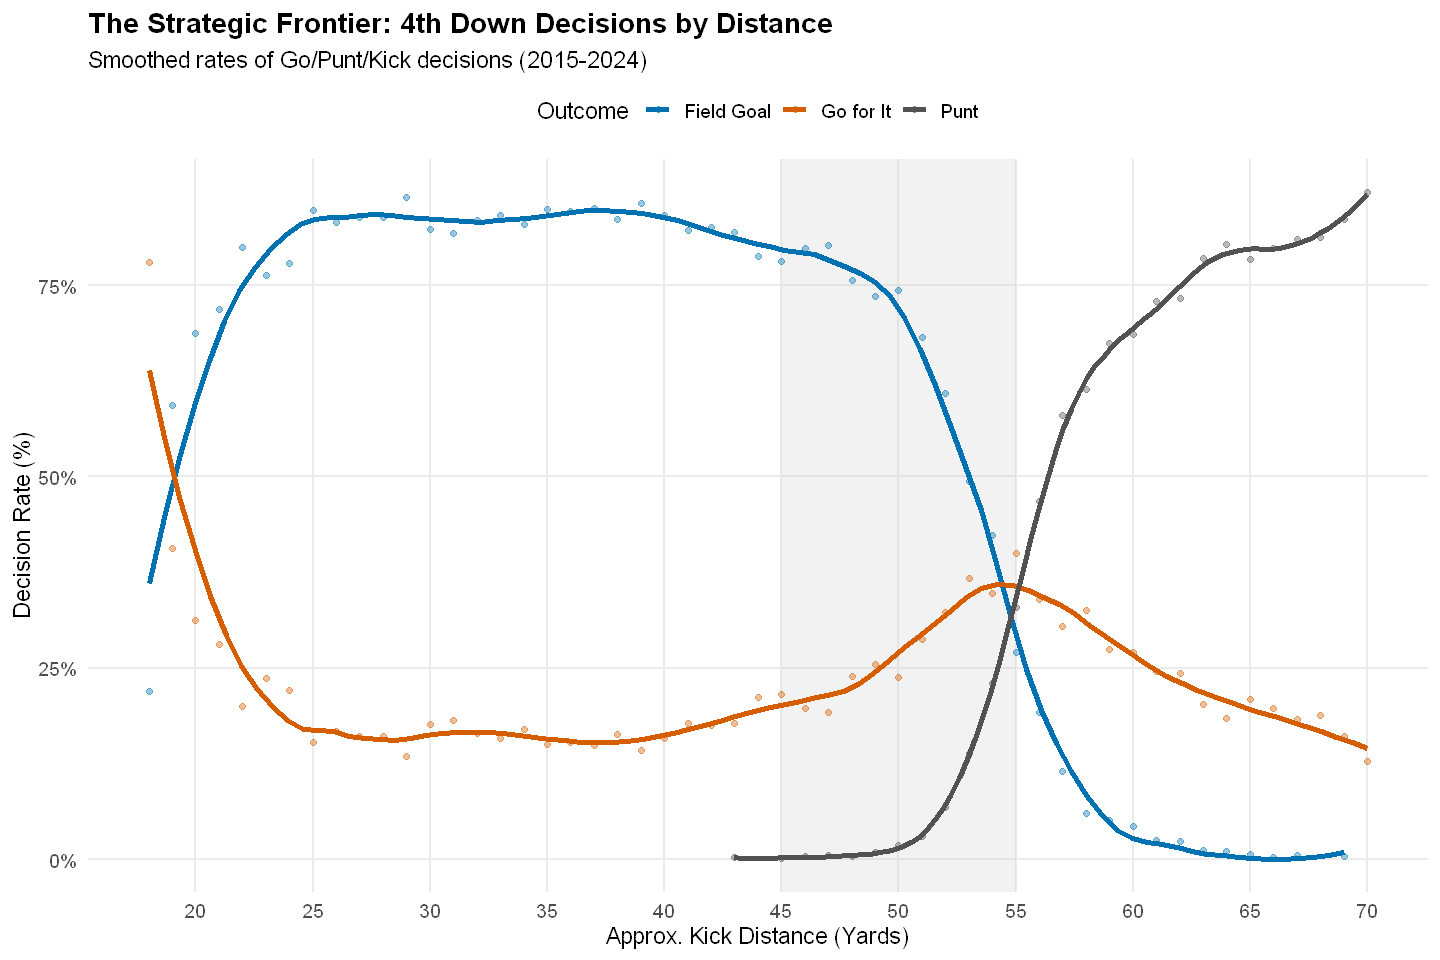

In [12]:
# ==============================================================================
# Strategic Landscape: Decision Rates by Distance (Go vs. Punt vs. Kick)
# ==============================================================================

# 1. Prepare Data (Multi-Class)
strategy_multi <- decision %>%
  # Filter for relevant field position (Opponent 45 to Goal Line)
  # yardline_100: 1 = Goal line, 99 = Own 1 yard line
  # We focus on the decision zone: 0 to 80 yards out
  filter(yardline_100 <= 80, yardline_100 >= 1) %>% 
  mutate(
    # Create a clean Outcome label
    Outcome = dplyr::case_when(
      action == "FG" ~ "Field Goal",
      action == "punt" ~ "Punt",
      action == "go_for_it" ~ "Go for It"
    ),
    # Approximate FG Distance (Yardline + 17/18 yds)
    approx_fg_dist = yardline_100 + 17
  ) %>%
  # Group by Distance and Outcome to get counts
  group_by(approx_fg_dist, Outcome) %>%
  summarise(n = n(), .groups = "drop_last") %>%
  # Calculate Rate: n / total plays at this distance
  mutate(
    total_plays = sum(n),
    rate = n / total_plays
  ) %>%
  ungroup() %>%
  # Filter noisy buckets (rare distances)
  filter(total_plays > 20)

# 2. Visualization
# Define Colors: Green (Punt), Blue (Kick), Yellow/Red (Go)
outcome_cols <- c("Punt" = "#525252", "Field Goal" = "#0072B2", "Go for It" = "#D55E00")

p_strategy <- ggplot(strategy_multi, aes(x = approx_fg_dist, y = rate, color = Outcome, fill = Outcome)) +
  
  # Highlight "No Man's Land" (Approx 48-58 yard FG range / 31-41 yardline)
  annotate("rect", xmin = 45, xmax = 55, ymin = -Inf, ymax = Inf, 
           fill = "grey", alpha = 0.2) +
  
  # Smooth Lines (The Trends)
  geom_smooth(method = "loess", span = 0.3, size = 1.5, se = FALSE) +
  
  # Points (Optional: reduced opacity to reduce clutter)
  geom_point(alpha = 0.4, size = 1.5) +
  
  # Formatting
  scale_color_manual(values = outcome_cols) +
  scale_fill_manual(values = outcome_cols) +
  scale_y_continuous(labels = scales::percent) +
  scale_x_continuous(breaks = seq(20, 80, 5)) +
  
  labs(
    title = "The Strategic Frontier: 4th Down Decisions by Distance",
    subtitle = "Smoothed rates of Go/Punt/Kick decisions (2015-2024)",
    x = "Approx. Kick Distance (Yards)",
    y = "Decision Rate (%)"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    plot.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

# Display
options(repr.plot.width = 12, repr.plot.height = 8)
print(p_strategy)

# Save
if(exists("reports_dir")) {
  ggsave(filename = file.path(reports_dir, "strategic_censoring_multi_curve.png"), 
         plot = p_strategy, width = 12, height = 8)
}

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 8 rows containing missing values or values outside the scale range
(`geom_smooth()`)."
`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 8 rows containing missing values or values outside the scale range
(`geom_smooth()`)."


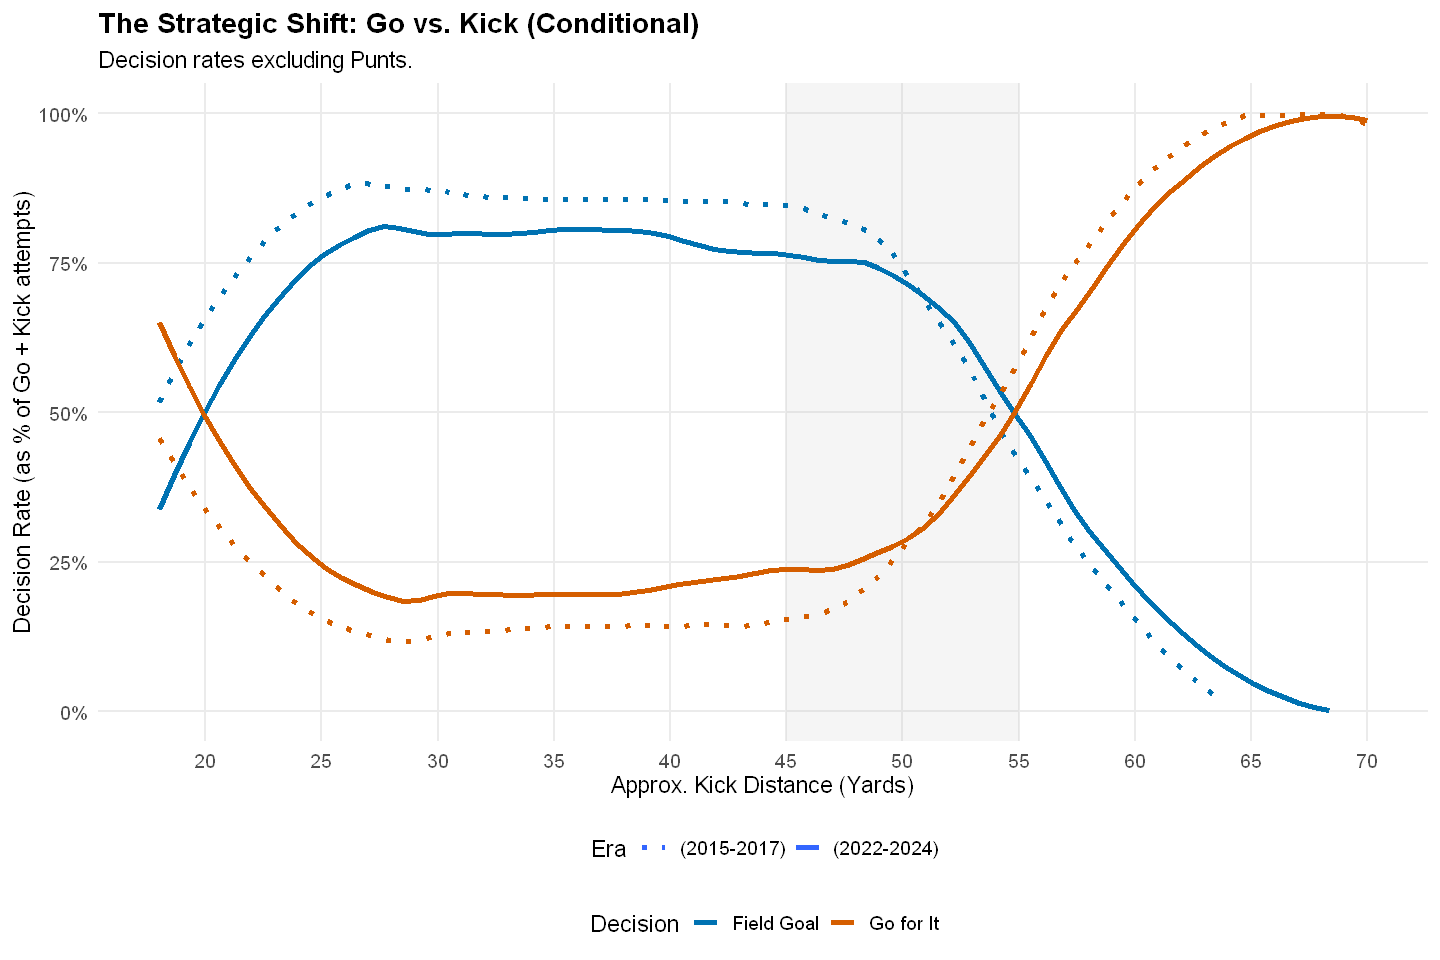

In [28]:
library(tidyverse)

# ==============================================================================
# The Analytics Revolution: Go vs. Kick Decision Rates (Era Comparison)
# ==============================================================================

# 1. Prepare Data
# We use the logic from your working code but filter for Punts/Go/Kick focus
strategy_era_compare <- decision %>%
  # Define Eras (Using robust %in% logic)
  mutate(
    Era = case_when(
      season %in% 2015:2017 ~ "(2015-2017)",
      season %in% 2022:2024 ~ "(2022-2024)",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(Era)) %>%
  
  # Filter for relevant field position
  filter(yardline_100 <= 80, yardline_100 >= 1) %>% 
  
  # EXCLUDE PUNTS: Focus strictly on the "Score Now" decision trade-off
  filter(action != "punt") %>% 
  
  mutate(
    Outcome = dplyr::case_when(
      action == "FG" ~ "Field Goal",
      action == "go_for_it" ~ "Go for It",
      TRUE ~ NA_character_
    ),
    approx_fg_dist = yardline_100 + 17
  ) %>%
  filter(!is.na(Outcome)) %>%
  
  # Group and Calculate Rates
  group_by(Era, approx_fg_dist, Outcome) %>%
  summarise(n = n(), .groups = "drop_last") %>%
  mutate(
    # Denominator = (Go + Kick). This visualizes the substitution effect.
    total_plays = sum(n), 
    rate = n / total_plays
  ) %>%
  ungroup() %>%
  # Filter out noisy buckets (e.g., deep territory where punts usually happen)
  filter(total_plays > 10)

# 2. Visualization
# Colors: Blue for Kick, Red for Go
outcome_cols <- c("Field Goal" = "#0072B2", "Go for It" = "#D55E00")

p_era_compare <- ggplot(strategy_era_compare, aes(x = approx_fg_dist, y = rate, color = Outcome, linetype = Era)) +
  
  # Highlight "No Man's Land" (50-60 yards)
  annotate("rect", xmin = 45, xmax = 55, ymin = -Inf, ymax = Inf, 
           fill = "grey", alpha = 0.15) +
  
  # Smooth Lines
  geom_smooth(method = "loess", span = 0.5, size = 1.5, se = FALSE) +
  
  # Formatting
  scale_color_manual(values = outcome_cols) +
  scale_linetype_manual(values = c("(2015-2017)" = "dotted", "(2022-2024)" = "solid")) +
  scale_y_continuous(labels = scales::percent, limits = c(0, 1)) +
  scale_x_continuous(breaks = seq(20, 80, 5)) +
  
  labs(
    title = "The Strategic Shift: Go vs. Kick (Conditional)",
    subtitle = "Decision rates excluding Punts.",
    x = "Approx. Kick Distance (Yards)",
    y = "Decision Rate (as % of Go + Kick attempts)",
    color = "Decision",
    linetype = "Era"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.box = "vertical",
    plot.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

# Display
options(repr.plot.width = 12, repr.plot.height = 8)
print(p_era_compare)

# Save
if(exists("reports_dir")) {
  ggsave(filename = file.path(reports_dir, "strategic_shift_direct_compare.png"), 
         plot = p_era_compare, width = 12, height = 8)
}

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


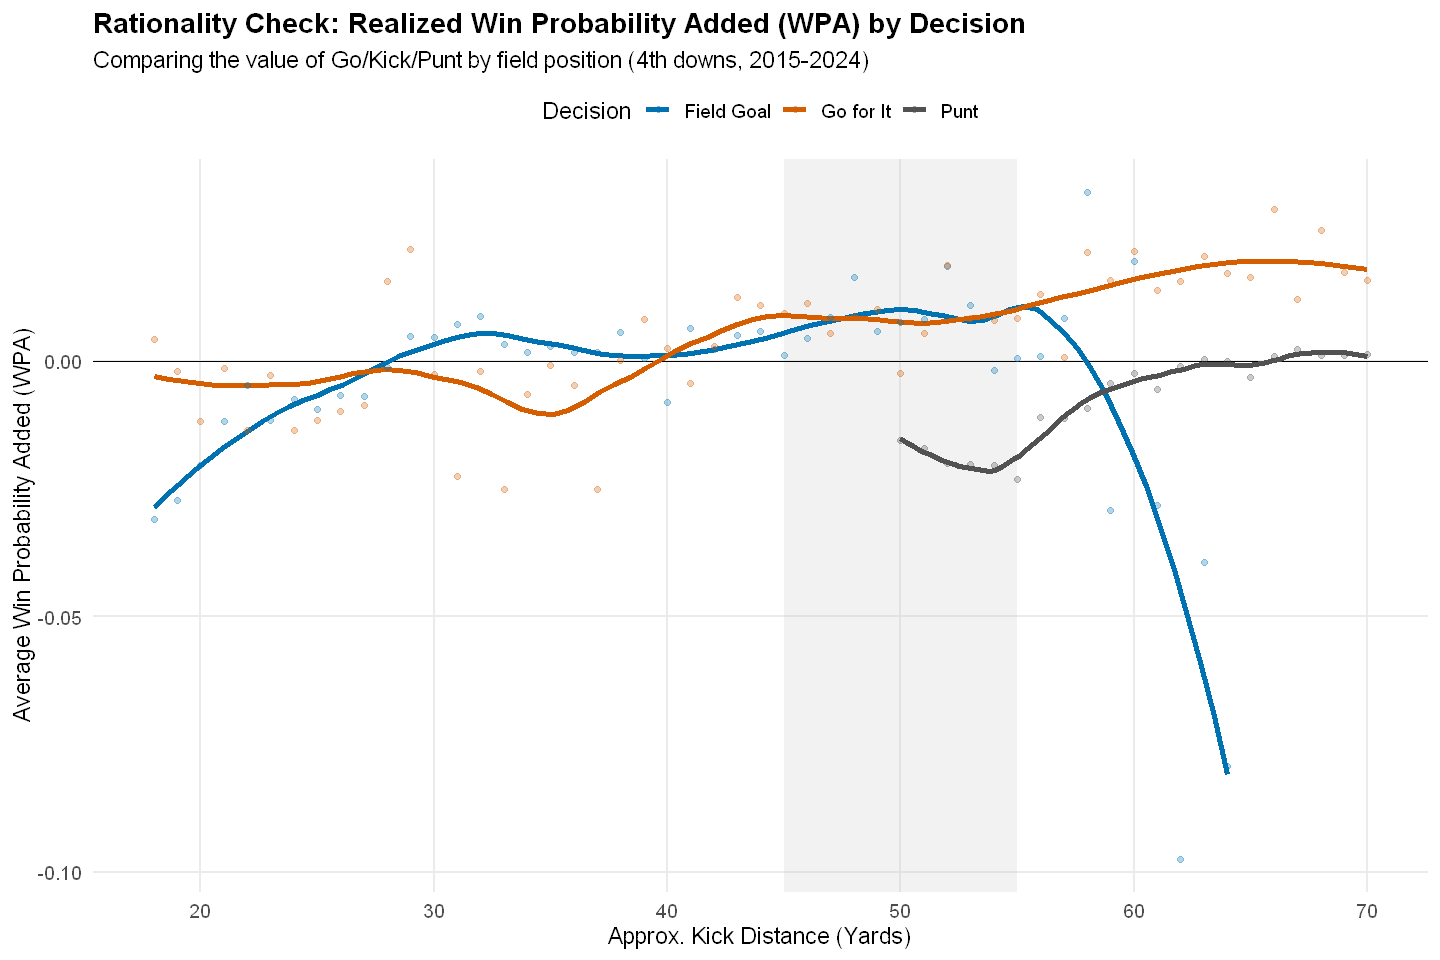

In [14]:
library(tidyverse)

# ==============================================================================
# The Rational Choice: WPA Trends by Field Position
# ==============================================================================

# 1. Prepare Data
# Filter for 4th downs with valid WPA
wpa_data <- decision %>%
  filter( !is.na(wpa), !is.na(yardline_100)) %>%
  # Focus on the decision zone (Own 40 to Goal Line)
  filter(yardline_100 <= 60, yardline_100 >= 1) %>%
  mutate(
    # Create Clean Labels
    Decision = case_when(
      action == "FG" ~ "Field Goal",
      action == "punt" ~ "Punt",
      action %in% c("go_for_it", "run", "pass") ~ "Go for It",
      TRUE ~ NA_character_
    ),
    approx_fg_dist = yardline_100 + 17
  ) %>%
  filter(!is.na(Decision))


# 2. Calculate Mean EPA per Yard Line (Pre-smoothing aggregation)
# This reduces noise from extreme outliers before the Loess smooth
wpa_summary <- wpa_data %>%
  group_by(Decision, approx_fg_dist) %>%
  summarise(
    n = n(),
    mean_wpa = mean(wpa, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(n > 5) # Remove noisy/rare yardlines

# 3. Visualization
# Define Palette (Consistent with previous)
decision_cols <- c("Punt" = "#525252", "Field Goal" = "#0072B2", "Go for It" = "#D55E00")

p_wpa_smooth <- ggplot(wpa_summary, aes(x = approx_fg_dist, y = mean_wpa, color = Decision)) +
  
  # Highlight "No Man's Land" (33-42 yard line)
  annotate("rect", xmin = 45, xmax = 55, ymin = -Inf, ymax = Inf, 
           fill = "grey", alpha = 0.2) +
  
  # Reference Line (0 EPA)
  geom_hline(yintercept = 0, linetype = "solid", color = "black", size = 0.5) +
  
  # Smoothed Lines (Loess)
  geom_smooth(method = "loess", span = 0.4, size = 1.5, se = FALSE) +
  
  # Points (Optional: Shows the raw averages behind the smooth)
  geom_point(alpha = 0.3, size = 1.5) +
  
  # Formatting
  scale_color_manual(values = decision_cols) +
  labs(
    title = "Rationality Check: Realized Win Probability Added (WPA) by Decision",
    subtitle = "Comparing the value of Go/Kick/Punt by field position (4th downs, 2015-2024)",
    x = "Approx. Kick Distance (Yards)",
    y = "Average Win Probability Added (WPA)"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    plot.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

# Display
options(repr.plot.width = 12, repr.plot.height = 8)
print(p_wpa_smooth)

# Save
if(exists("reports_dir")) {
  ggsave(filename = file.path(reports_dir, "wpa_landscape_smoothed.png"), 
         plot = p_wpa_smooth, width = 12, height = 8)
}

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


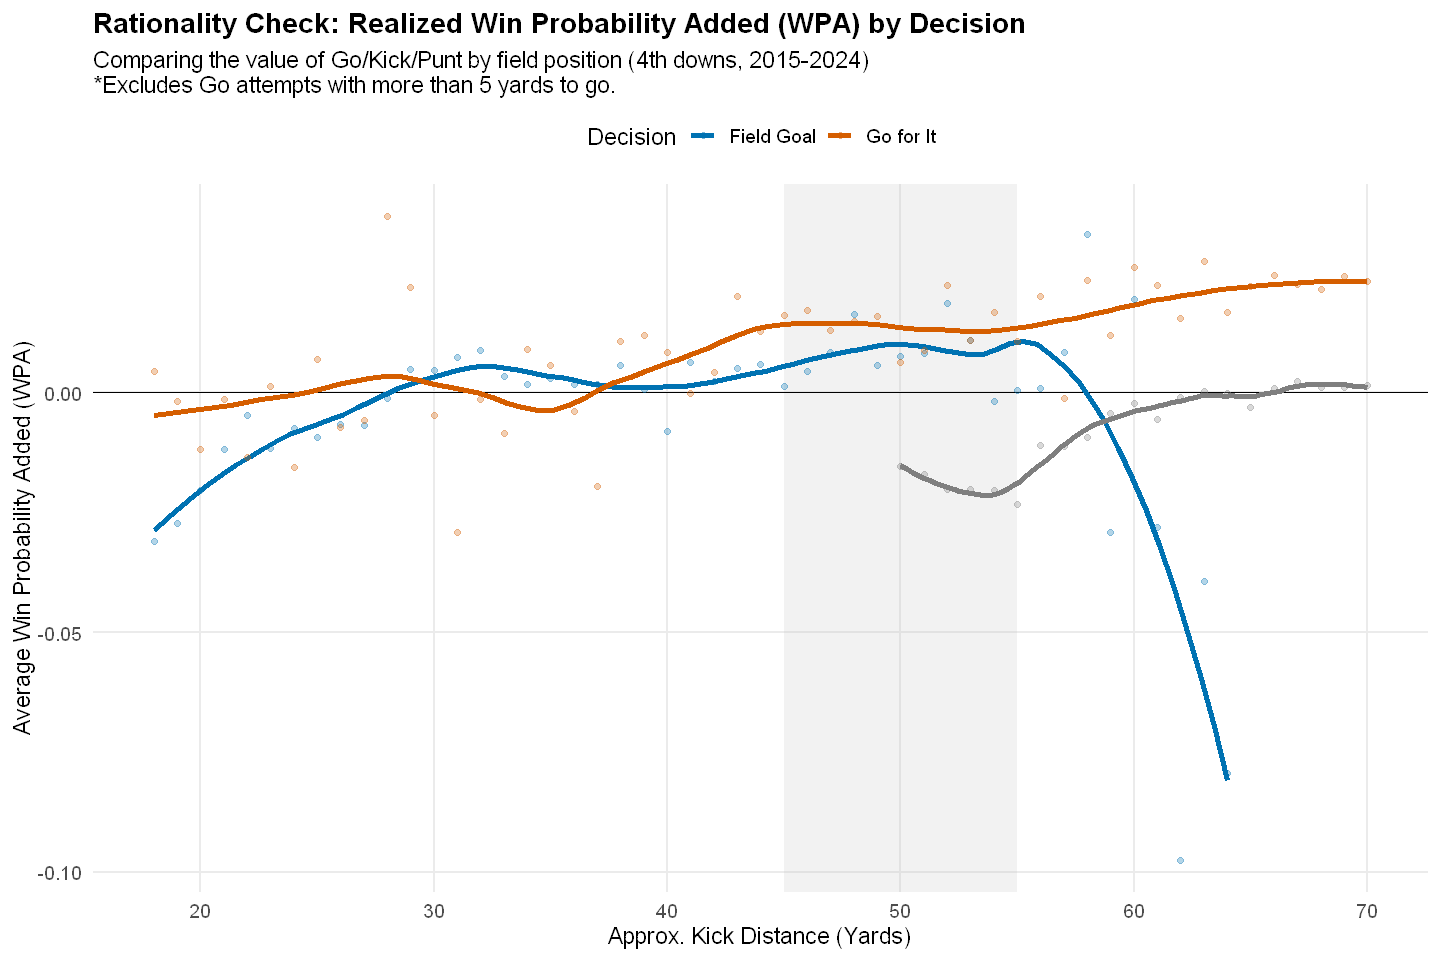

In [27]:
library(tidyverse)

# ==============================================================================
# The Rational Choice: WPA Trends by Field Position
# ==============================================================================

# 1. Prepare Data
# Filter for 4th downs with valid WPA
wpa_data <- decision %>%
  filter( !is.na(wpa), !is.na(yardline_100)) %>%
  # Focus on the decision zone (Own 40 to Goal Line)
  filter(yardline_100 <= 60, yardline_100 >= 1) %>%
  mutate(
    # Create Clean Labels
    Decision = case_when(
      action == "FG" ~ "Field Goal",
      action == "punt" ~ "Punt",
      action %in% c("go_for_it", "run", "pass") ~ "Go for It",
      TRUE ~ NA_character_
    ),
    approx_fg_dist = yardline_100 + 17
  ) %>%
  #filter out go_for_it plays with very long to-go distances
  filter(!(Decision == "Go for It" & ydstogo > 5)) %>%
  filter(!is.na(Decision))


# 2. Calculate Mean WPA per Yard Line (Pre-smoothing aggregation)
# This reduces noise from extreme outliers before the Loess smooth
wpa_summary <- wpa_data %>%
  group_by(Decision, approx_fg_dist) %>%
  summarise(
    n = n(),
    mean_wpa = mean(wpa, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(n > 5) # Remove noisy/rare yardlines

# 3. Visualization


p_wpa_smooth <- ggplot(wpa_summary, aes(x = approx_fg_dist, y = mean_wpa, color = Decision)) +
  
  # Highlight "No Man's Land" (33-42 yard line)
  annotate("rect", xmin = 45, xmax = 55, ymin = -Inf, ymax = Inf, 
           fill = "grey", alpha = 0.2) +
  
  # Reference Line (0 EPA)
  geom_hline(yintercept = 0, linetype = "solid", color = "black", size = 0.5) +
  
  # Smoothed Lines (Loess)
  geom_smooth(method = "loess", span = 0.4, size = 1.5, se = FALSE) +
  
  # Points (Optional: Shows the raw averages behind the smooth)
  geom_point(alpha = 0.3, size = 1.5) +
  
  # Formatting
  scale_color_manual(values = decision_cols) +
  labs(
    title = "Rationality Check: Realized Win Probability Added (WPA) by Decision",
    subtitle = "Comparing the value of Go/Kick/Punt by field position (4th downs, 2015-2024)\n*Excludes Go attempts with more than 5 yards to go.",
    x = "Approx. Kick Distance (Yards)",
    y = "Average Win Probability Added (WPA)"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    plot.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

# Display
options(repr.plot.width = 12, repr.plot.height = 8)
print(p_wpa_smooth)

# Save
if(exists("reports_dir")) {
  ggsave(filename = file.path(reports_dir, "wpa_landscape_smoothed.png"), 
         plot = p_wpa_smooth, width = 12, height = 8)
}

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


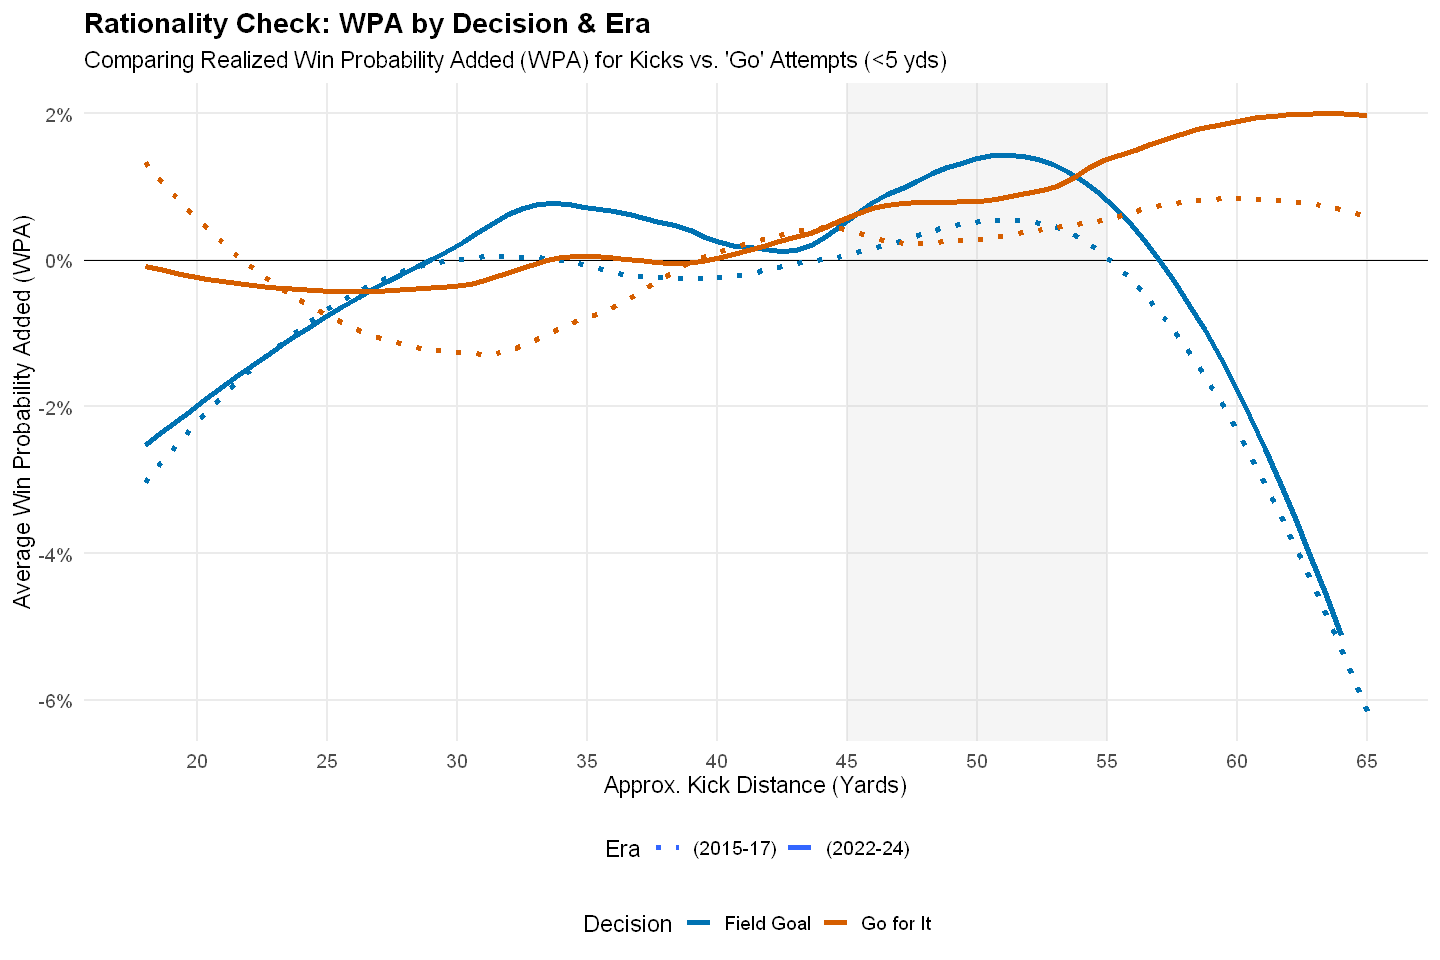

In [25]:
library(tidyverse)

# ==============================================================================
# The Rational Choice: WPA Trends (Era Comparison)
# ==============================================================================

# 1. Prepare Data
wpa_era_data <- decision %>%
  # Define Eras (Robust numeric check)
  mutate(season = as.numeric(season)) %>%
  mutate(
    Era = case_when(
      season >= 2015 & season <= 2017 ~ "(2015-17)",
      season >= 2022 & season <= 2024 ~ "(2022-24)",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(Era)) %>%
  
  # Filter for 4th downs with valid WPA
  filter(!is.na(wpa), !is.na(yardline_100)) %>%
  
  # Focus on the decision zone (Own 40 to Goal Line)
  filter(yardline_100 <= 48, yardline_100 >= 1) %>%
  
  mutate(
    Decision = case_when(
      action == "FG" ~ "Field Goal",
      action %in% c("go_for_it", "run", "pass") ~ "Go for It",
      TRUE ~ NA_character_
    ),
    approx_fg_dist = yardline_100 + 17
  ) %>%
  
  # Filter strictly for FG vs Go
  filter(Decision %in% c("Field Goal", "Go for It")) #%>%
  
  # Filter out "Hail Mary" Go attempts (Keep it comparable to a FG decision)
  #filter(!(Decision == "Go for It" & ydstogo > 5))


# 2. Visualization
# Define Palette: Blue vs Vermilion
decision_cols <- c("Field Goal" = "#0072B2", "Go for It" = "#D55E00")

p_wpa_era <- ggplot(wpa_era_data, aes(x = approx_fg_dist, y = wpa, color = Decision, linetype = Era)) +
  
  # Highlight "No Man's Land" (Approx 45-55 yard FG range)
  annotate("rect", xmin = 45, xmax = 55, ymin = -Inf, ymax = Inf, 
           fill = "grey", alpha = 0.15) +
  
  # Reference Line (0 WPA)
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  
  # Smoothed Lines (Loess)
  # Se = FALSE cleans up the overlap
  geom_smooth(method = "loess", span = 0.6, size = 1.5, se = FALSE) +
  
  # Formatting
  scale_color_manual(values = decision_cols) +
  scale_linetype_manual(values = c("(2015-17)" = "dotted", "(2022-24)" = "solid")) +
  
  # Axis Breaks
  scale_x_continuous(breaks = seq(20, 70, 5)) +
  # --- NEW: Format Y-Axis as Percent ---
  scale_y_continuous(labels = scales::percent) +
  
  labs(
    title = "Rationality Check: WPA by Decision & Era",
    subtitle = "Comparing Realized Win Probability Added (WPA) for Kicks vs. 'Go' Attempts (<5 yds)",
    x = "Approx. Kick Distance (Yards)",
    y = "Average Win Probability Added (WPA)",
    color = "Decision",
    linetype = "Era",
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    legend.box = "vertical",
    plot.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

# Display
options(repr.plot.width = 12, repr.plot.height = 8)
print(p_wpa_era)

# Save
if(exists("reports_dir")) {
  ggsave(filename = file.path(reports_dir, "wpa_landscape_era_comparison.png"), 
         plot = p_wpa_era, width = 12, height = 8)
}

`geom_smooth()` using formula = 'y ~ x'


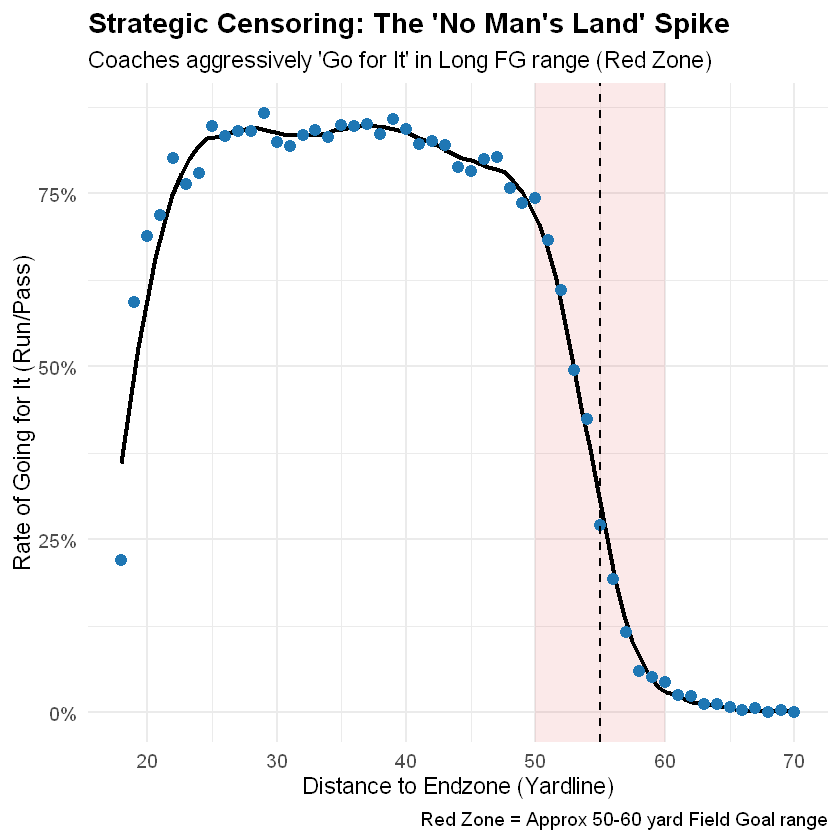

In [6]:
# 1. Prepare Data
# Using the 'decision' dataframe from your earlier step
strategy_check <- decision %>%
  filter(yardline_100 <= 65, yardline_100 >= 00) %>% # Focus on relevant zone
  mutate(
    # Convert Action to Binary "Go" (1) vs "Kick/Punt" (0)
    is_go = ifelse(action == "FG", 1, 0),
    # Approximate FG Distance for context (Yardline + 18)
    approx_fg_dist = yardline_100 + 17 
  ) %>%
  group_by(approx_fg_dist) %>%
  summarise(
    n = n(),
    go_rate = mean(is_go),
    .groups = "drop"
  ) %>%
  filter(n > 20) # Filter noisy bins

# 2. Visualization
ggplot(strategy_check, aes(x = approx_fg_dist, y = go_rate)) +
  # Highlight "No Man's Land" (33-42 yard line / ~50-60 yd FG)
  annotate("rect", xmin = 50, xmax = 60, ymin = -Inf, ymax = Inf, 
           fill = "#d62728", alpha = 0.1) +
  geom_smooth(method = "loess", span = 0.3, color = "black", se = FALSE) +
  geom_point(color = "#1f77b4", size = 3) +
  geom_vline(xintercept = 55, linetype = "dashed") + # Peak of No Man's Land
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Strategic Censoring: The 'No Man's Land' Spike",
    subtitle = "Coaches aggressively 'Go for It' in Long FG range (Red Zone)",
    x = "Distance to Endzone (Yardline)",
    y = "Rate of Going for It (Run/Pass)",
    caption = "Red Zone = Approx 50-60 yard Field Goal range"
  ) +
  theme_minimal(base_size = 14) +
  theme(plot.title = element_text(face = "bold"))

Generating decision plots with Sample Sizes (N)...


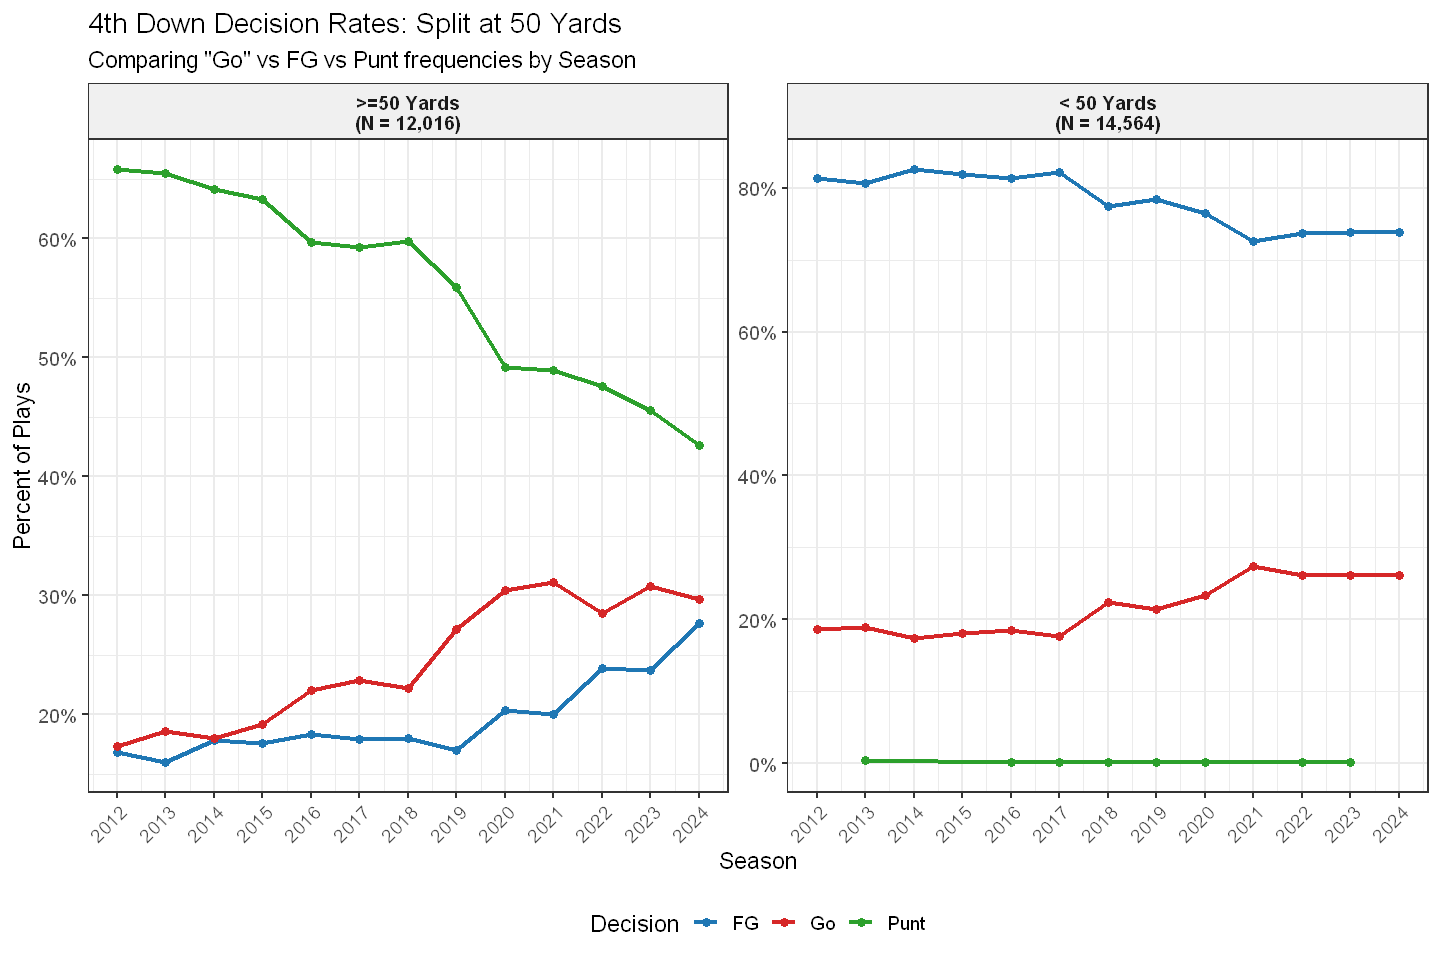

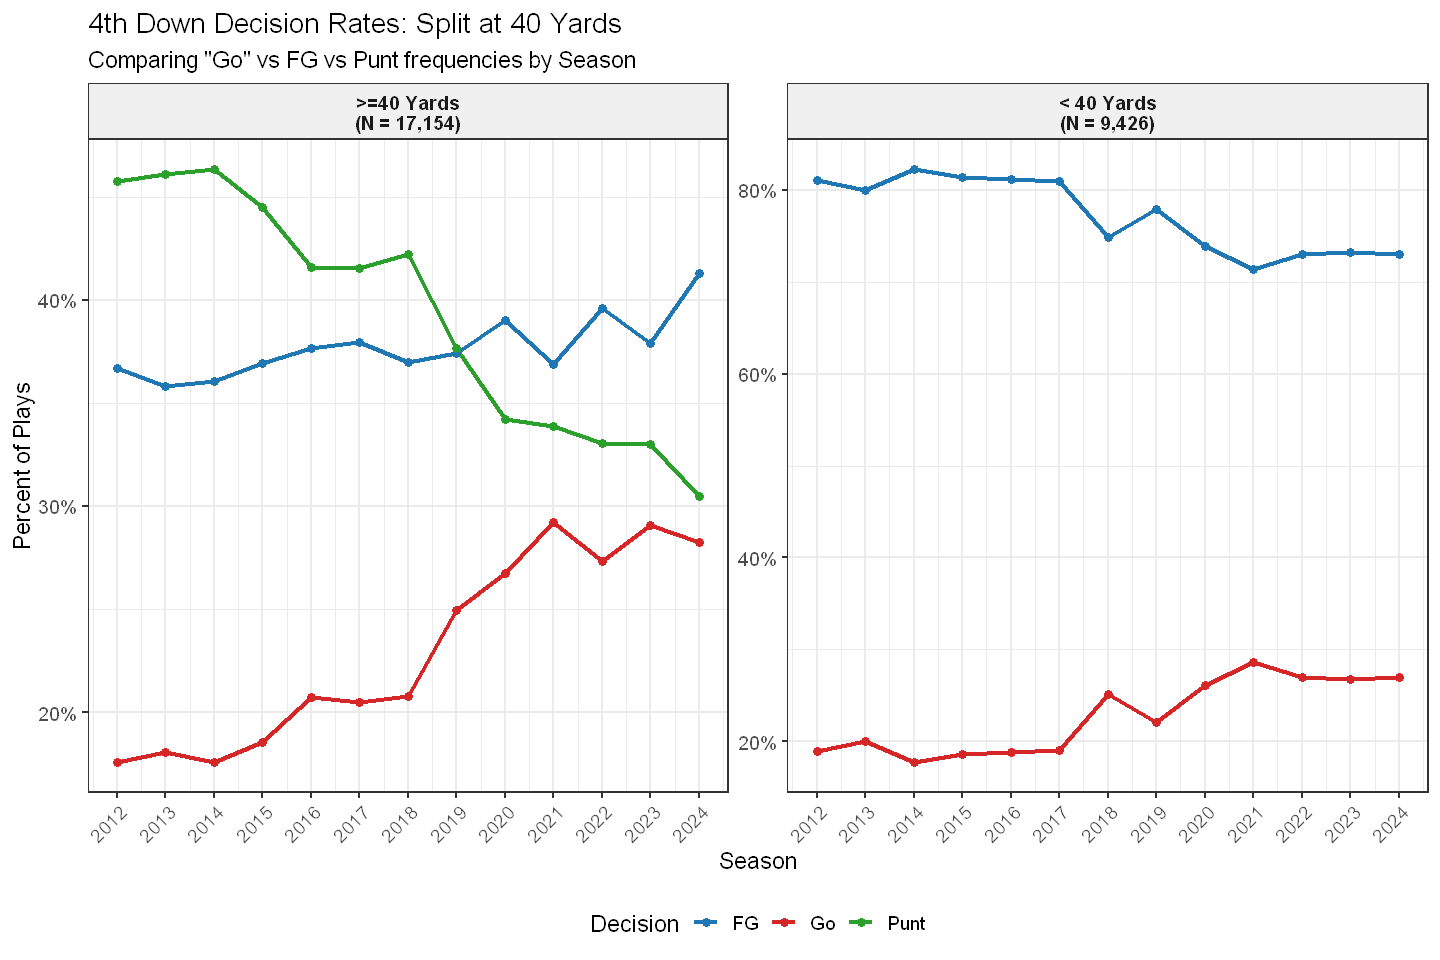

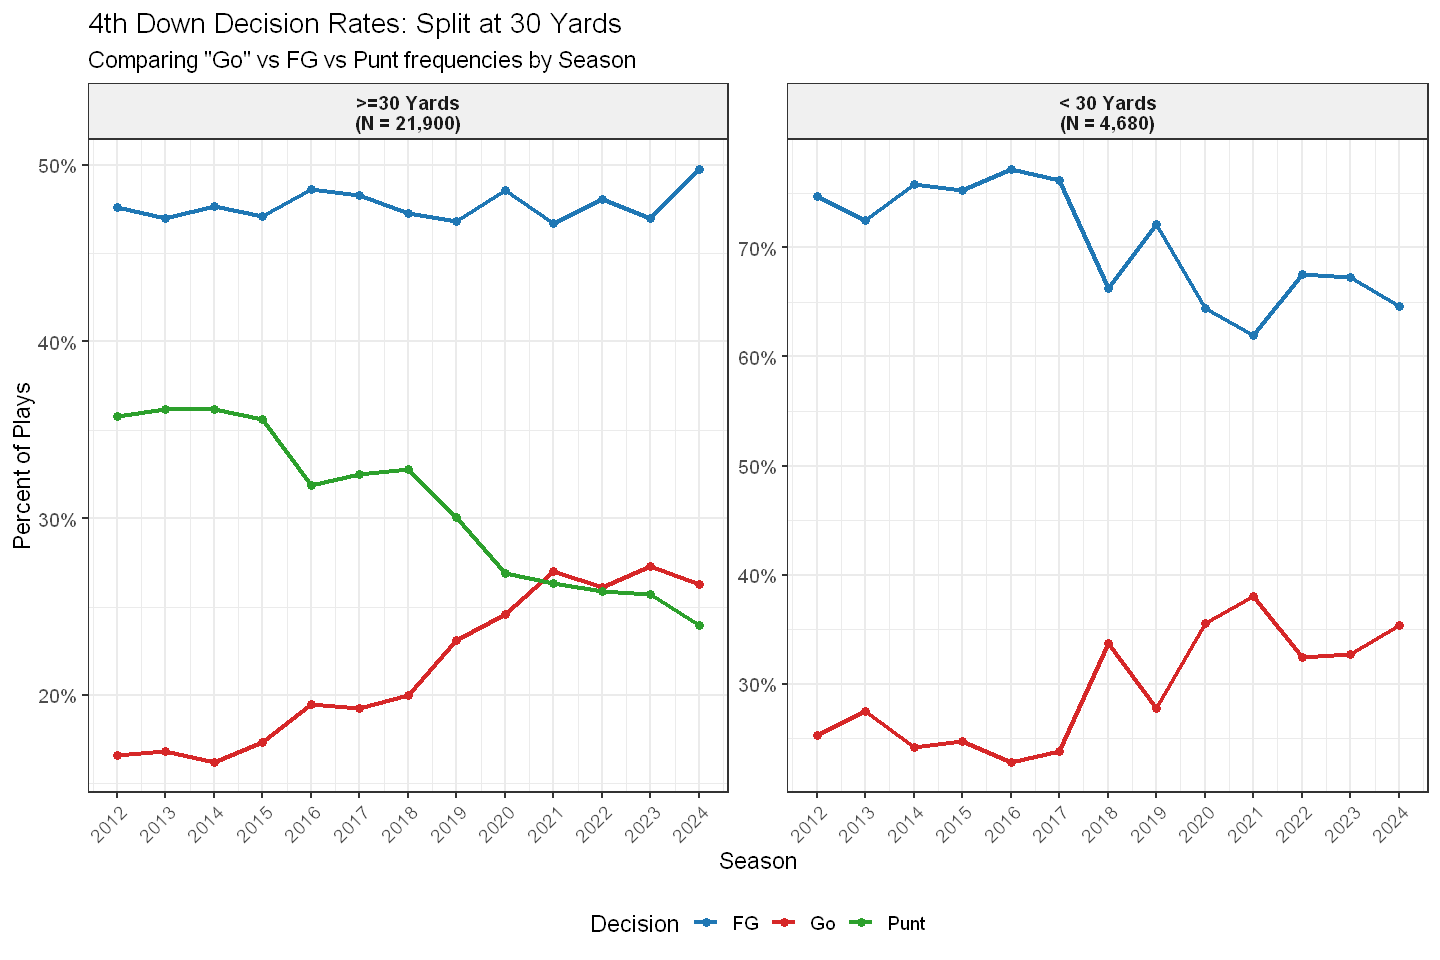

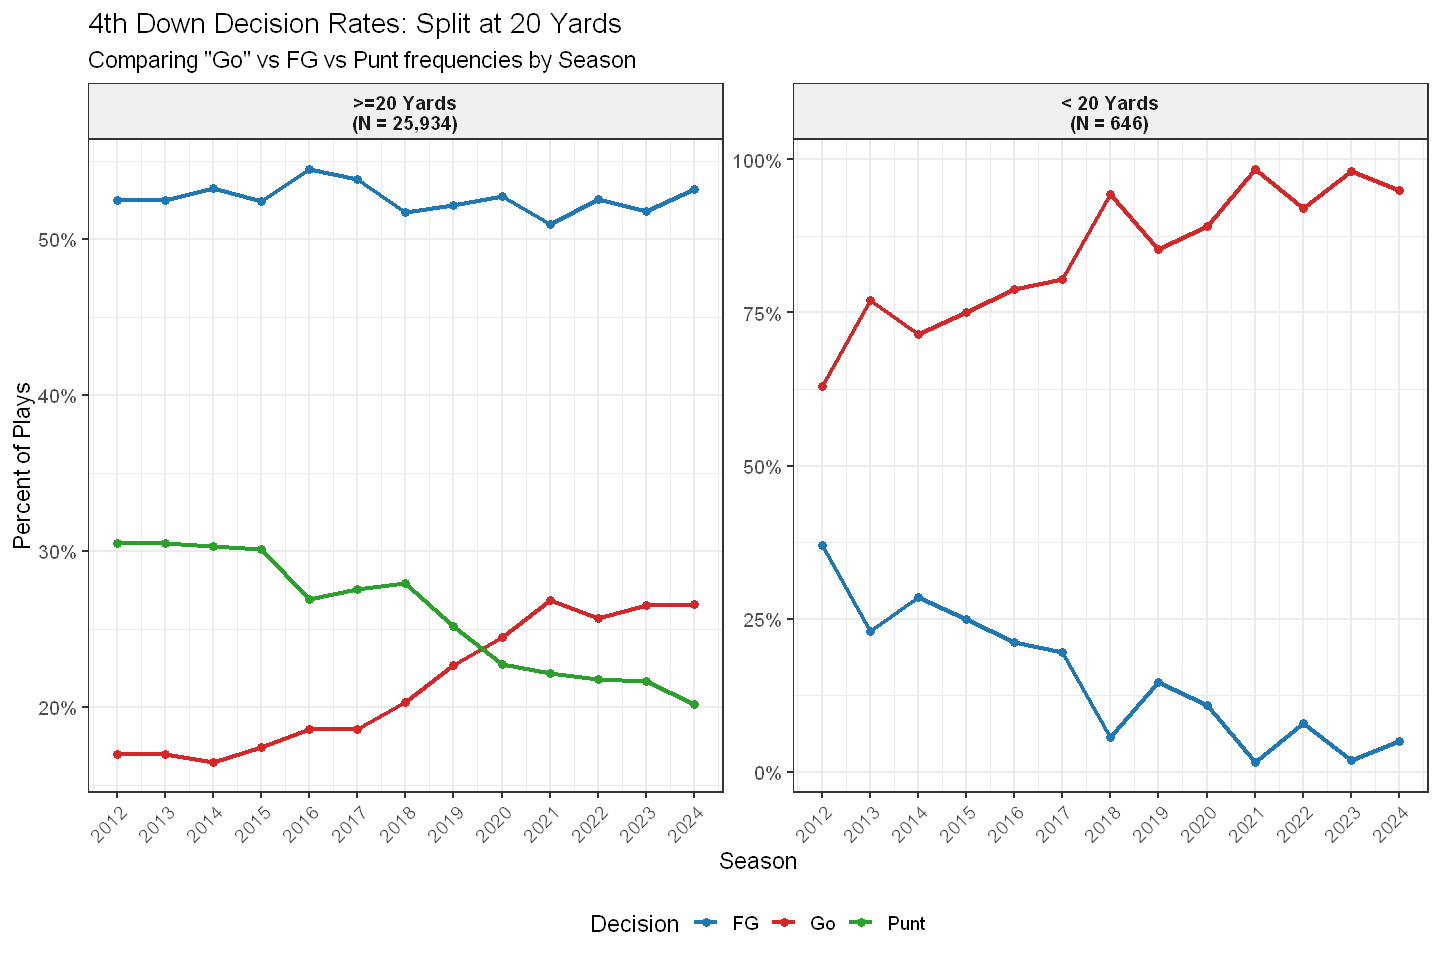

In [16]:
# ==============================================================================
# 4th Down Decision Analysis: Side-by-Side Splits (Using 'decision' dataframe)
# ==============================================================================

# 1. Directory Setup
reports_attempt_dir <- file.path(reports_dir, 'attempt_pi')
if (!dir.exists(reports_attempt_dir)) dir.create(reports_attempt_dir, recursive = TRUE, showWarnings = FALSE)
fig_dir <- file.path(reports_attempt_dir, 'figs')
if (!dir.exists(fig_dir)) dir.create(fig_dir, recursive = TRUE, showWarnings = FALSE)

# 2. Prep Data for Plotting
# We use your pre-calculated 'decision' dataframe.
# We create a clean 'play_label' for the legend/plot (Capitalized)
plot_base <- decision %>%
  dplyr::mutate(
    play_label = dplyr::case_when(
      action == 'go_for_it' ~ 'Go',
      action == 'punt' ~ 'Punt',
      action == 'FG' ~ 'FG',
      TRUE ~ action
    )
  )

# 3. Define Cutoffs
cutoffs <- c(50, 40, 30, 20)

# 4. Loop and Generate 4 Separate Plots
cat("Generating decision plots with Sample Sizes (N)...\n")
options(repr.plot.width = 12, repr.plot.height = 8)

for (cut in cutoffs) {
  
  # --- A. Calculate Upper Subset (>= Cut) ---
  data_ge <- plot_base %>% dplyr::filter(kick_distance >= cut)
  n_ge <- nrow(data_ge)
  label_ge <- paste0(">=", cut, " Yards\n(N = ", format(n_ge, big.mark=","), ")")
  
  rates_ge <- data_ge %>%
    dplyr::group_by(season, play_label) %>%
    dplyr::summarise(n = dplyr::n(), .groups = 'drop') %>%
    dplyr::group_by(season) %>%
    dplyr::mutate(total_season = sum(n), pct = n / total_season, subset = label_ge) %>%
    dplyr::ungroup()
  
  # --- B. Calculate Lower Subset (< Cut) ---
  data_lt <- plot_base %>% dplyr::filter(kick_distance < cut)
  n_lt <- nrow(data_lt)
  label_lt <- paste0("< ", cut, " Yards\n(N = ", format(n_lt, big.mark=","), ")")
  
  rates_lt <- data_lt %>%
    dplyr::group_by(season, play_label) %>%
    dplyr::summarise(n = dplyr::n(), .groups = 'drop') %>%
    dplyr::group_by(season) %>%
    dplyr::mutate(total_season = sum(n), pct = n / total_season, subset = label_lt) %>%
    dplyr::ungroup()
  
  # --- C. Combine ---
  plot_data <- dplyr::bind_rows(rates_ge, rates_lt)
  
  # Force Factor Order (>= Left, < Right)
  plot_data$subset <- factor(plot_data$subset, levels = c(label_ge, label_lt))
  
  # --- D. Plot ---
  p <- ggplot2::ggplot(plot_data, ggplot2::aes(x = season, y = pct, colour = play_label, group = play_label)) +
    ggplot2::geom_line(linewidth = 1.2) +
    ggplot2::geom_point(size = 2) +
    ggplot2::facet_wrap(~subset, ncol = 2, scales = "free_y") +
    ggplot2::scale_x_continuous(breaks = sort(unique(plot_data$season))) +
    ggplot2::scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    # Explicit colors for consistency
    ggplot2::scale_color_manual(values = c("FG" = "#1f77b4", "Go" = "#d62728", "Punt" = "#2ca02c")) +
    ggplot2::labs(
      title = paste0('4th Down Decision Rates: Split at ', cut, ' Yards'),
      subtitle = 'Comparing "Go" vs FG vs Punt frequencies by Season',
      x = 'Season', y = 'Percent of Plays', colour = 'Decision'
    ) +
    ggplot2::theme_bw(base_size = 14) +
    ggplot2::theme(
      legend.position = 'bottom',
      axis.text.x = ggplot2::element_text(angle = 45, hjust = 1),
      strip.background = ggplot2::element_rect(fill = "#f0f0f0"),
      strip.text = ggplot2::element_text(face = "bold")
    )
  
  # Save
  filename <- paste0('decision_rates_split_', cut, '_with_N.png')
  ggplot2::ggsave(filename = file.path(fig_dir, filename), plot = p, width = 12, height = 8)
  
  print(p)
}

Generating decision plots for distance buckets...


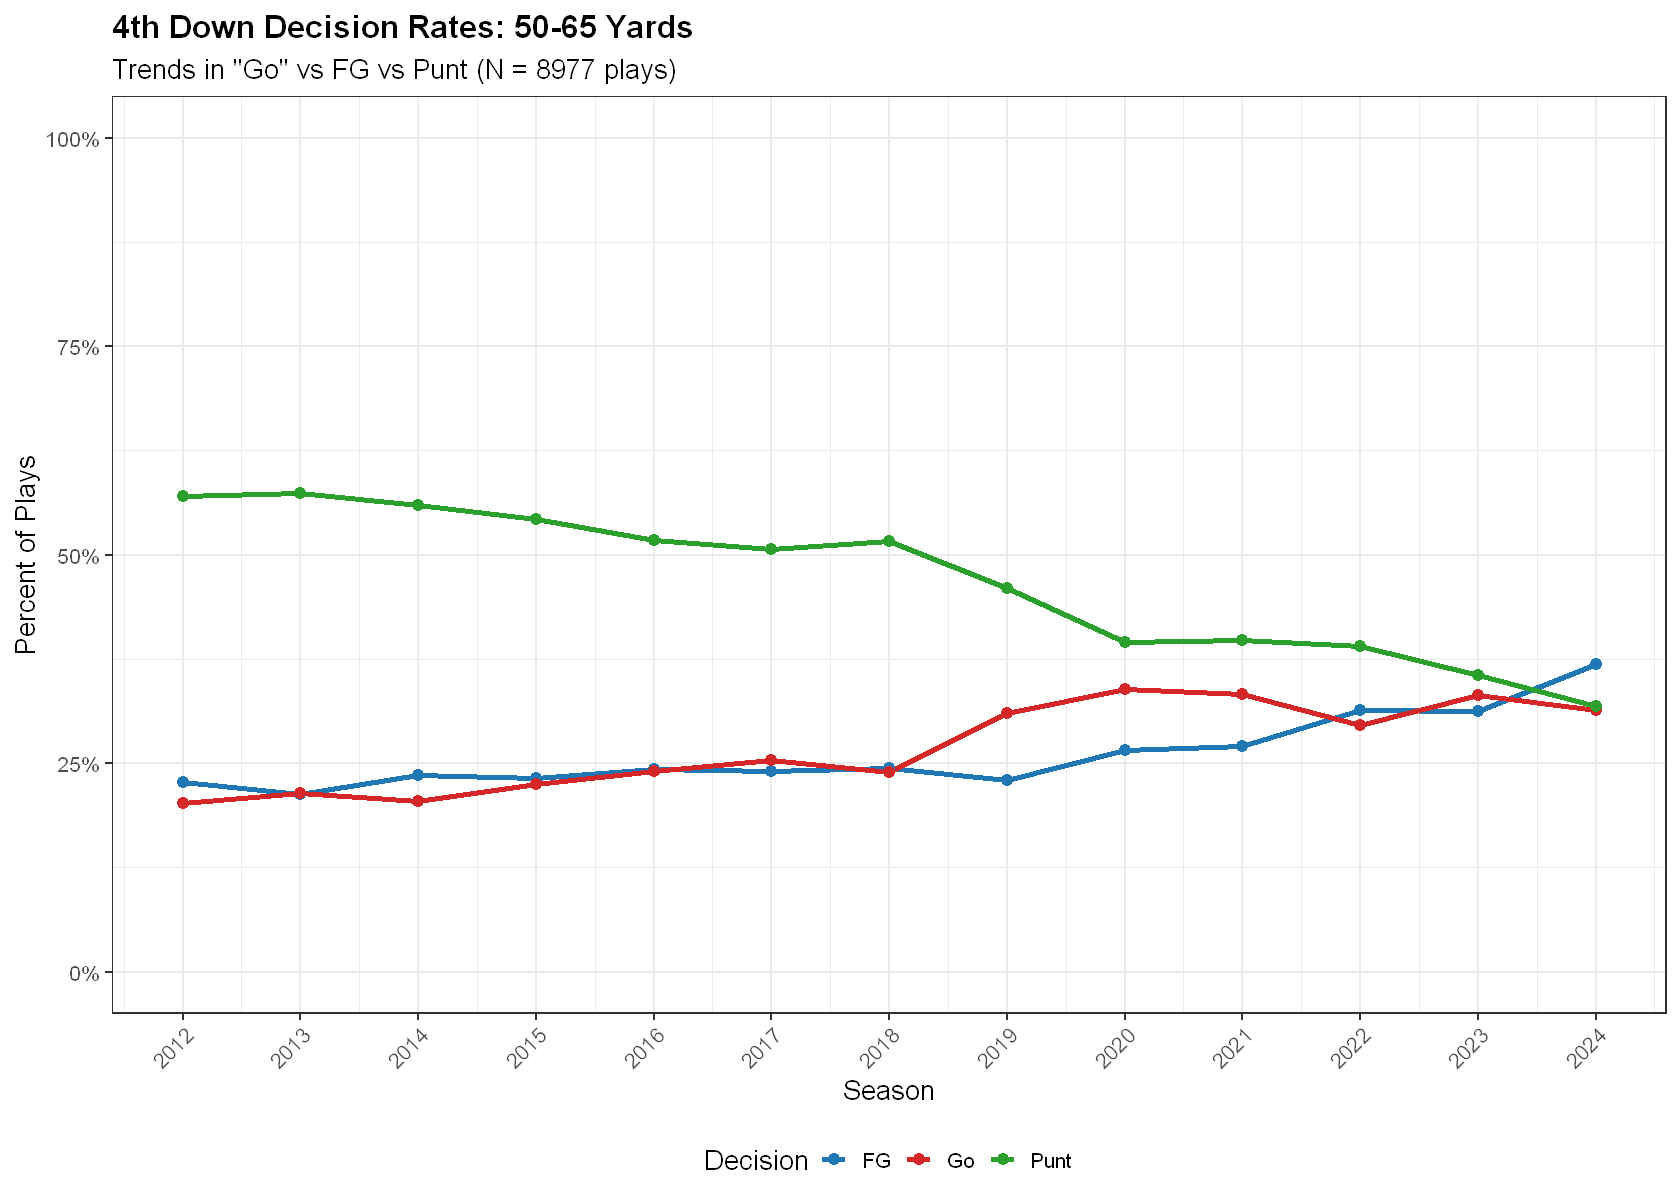

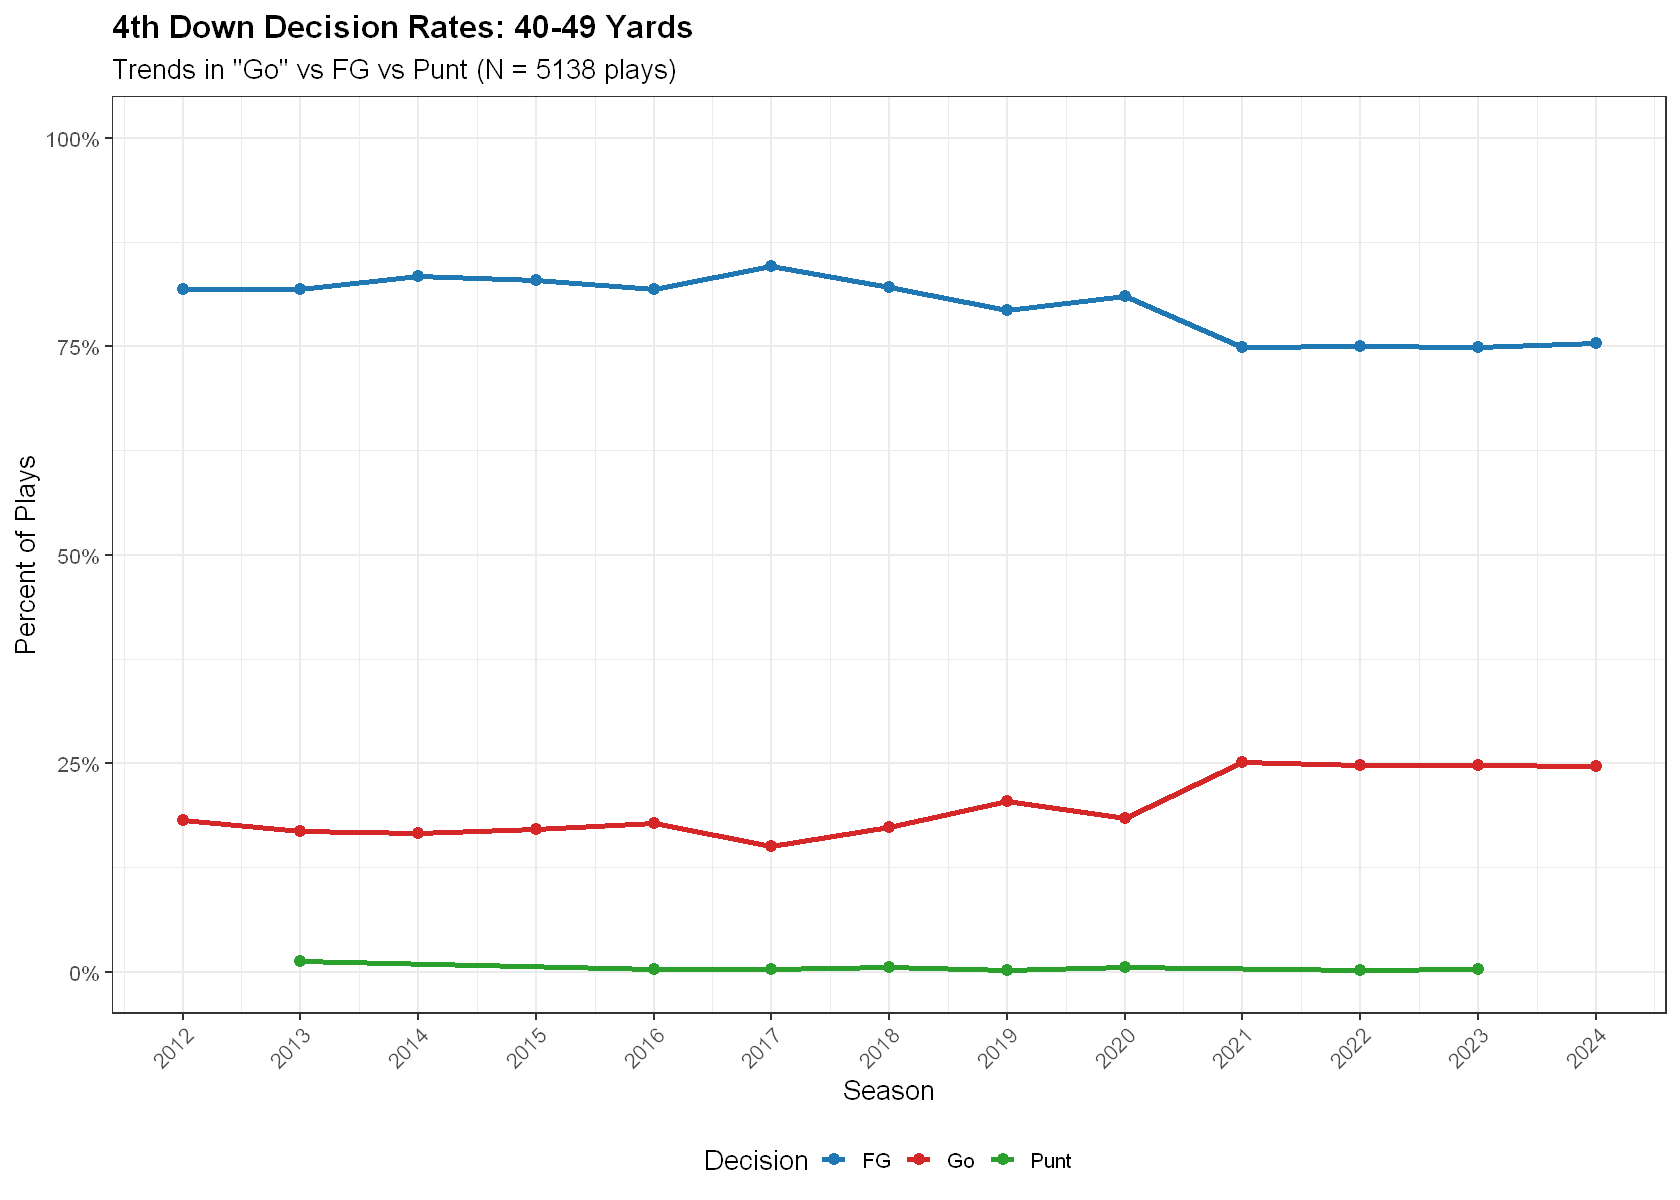

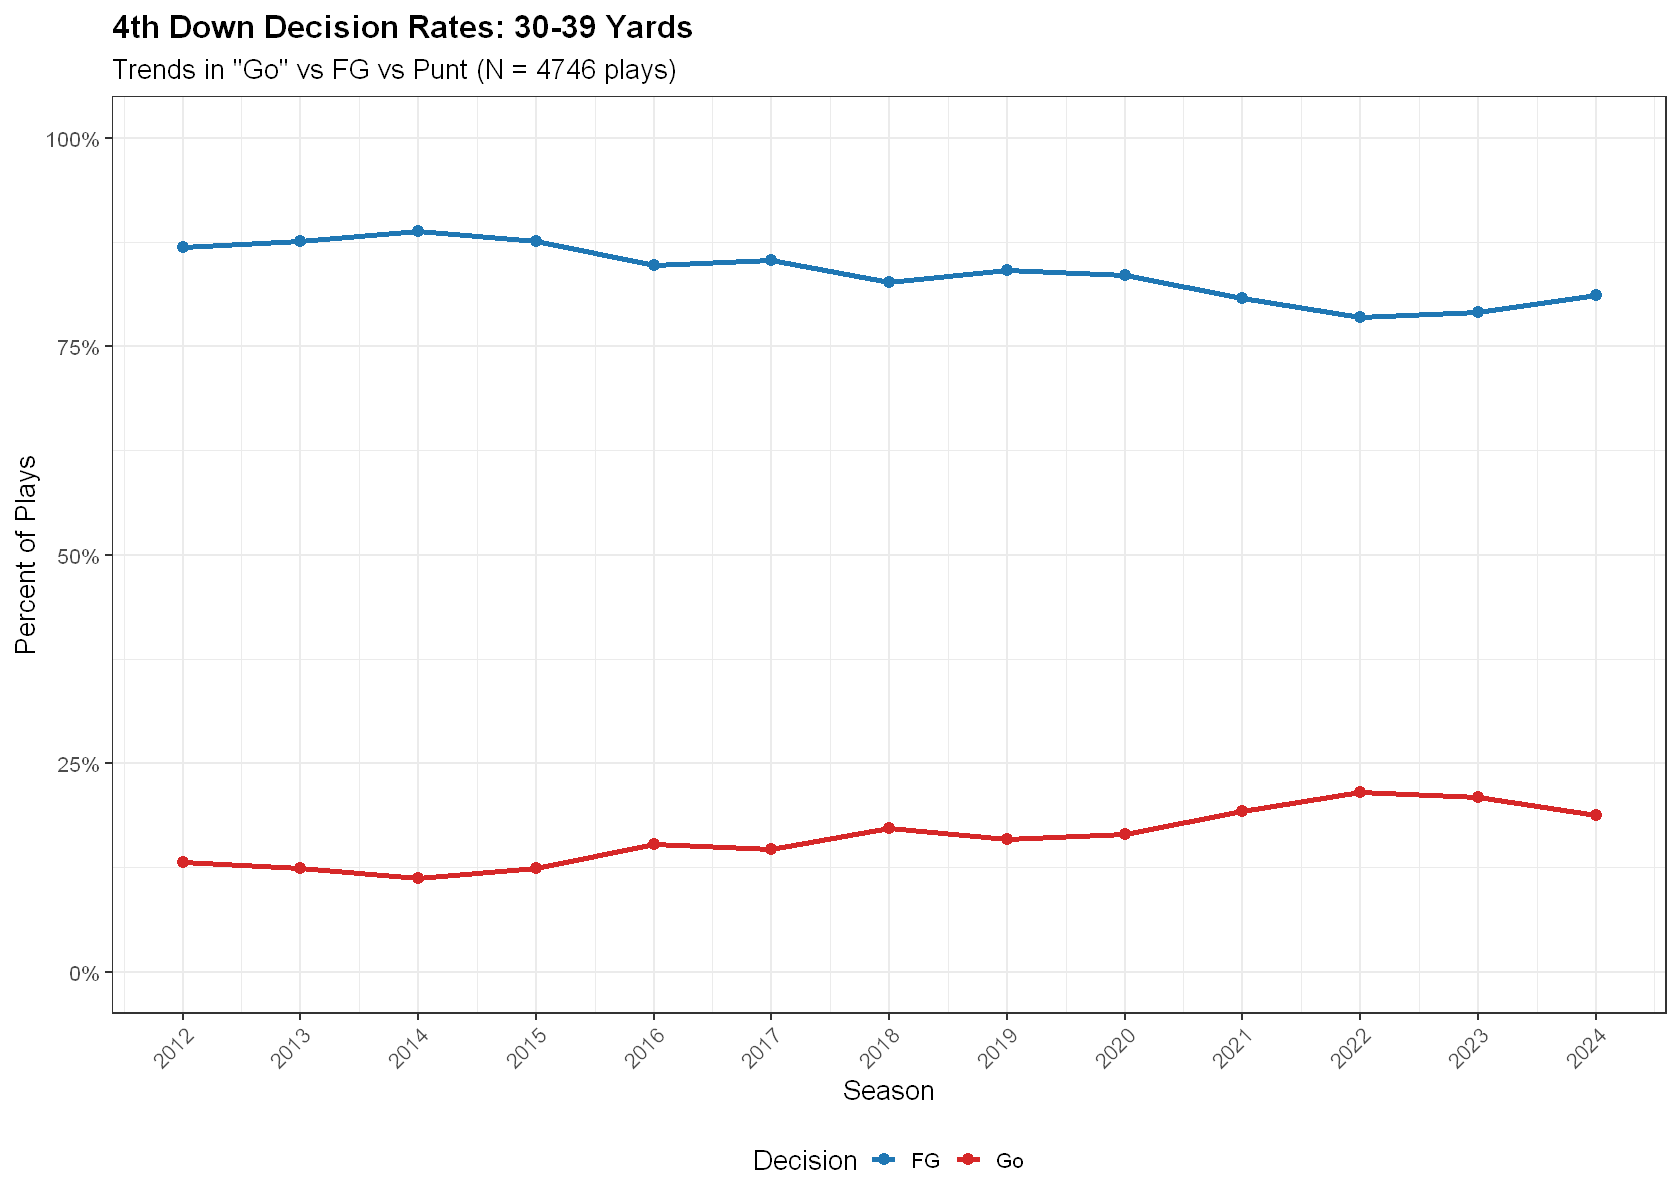

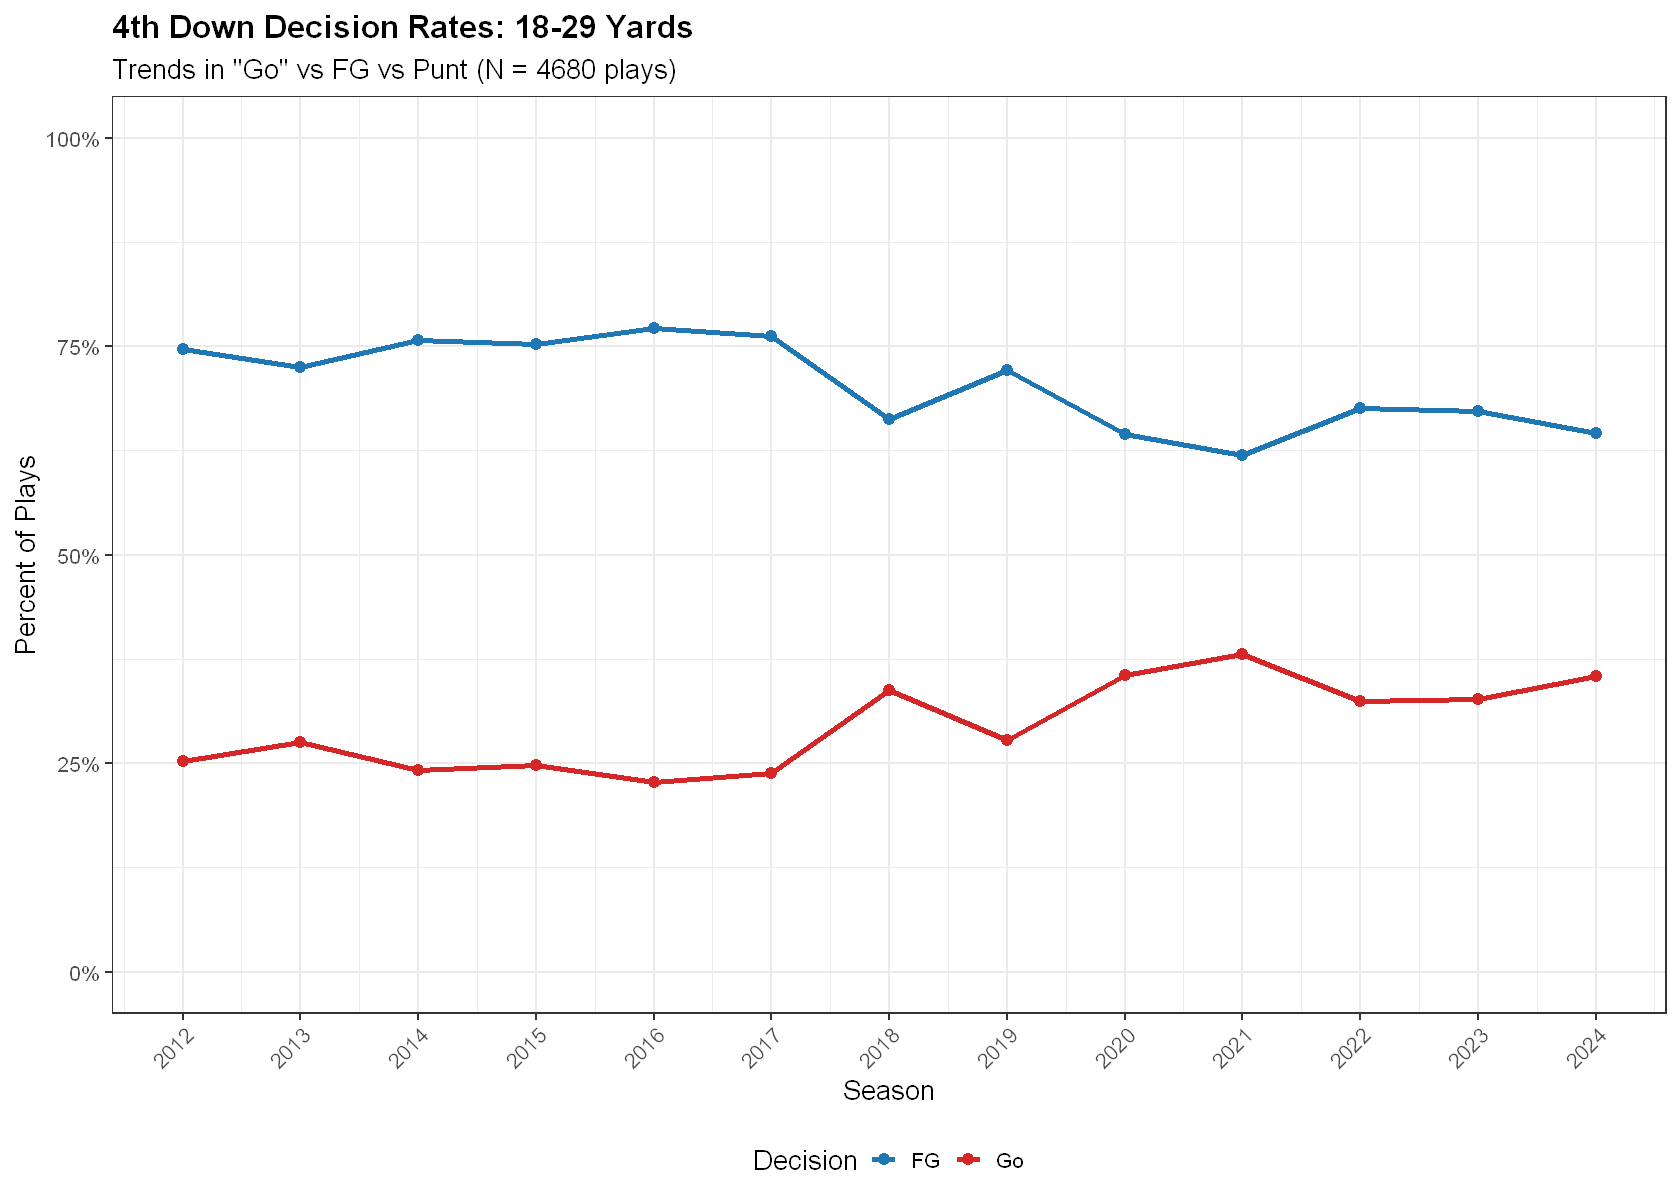

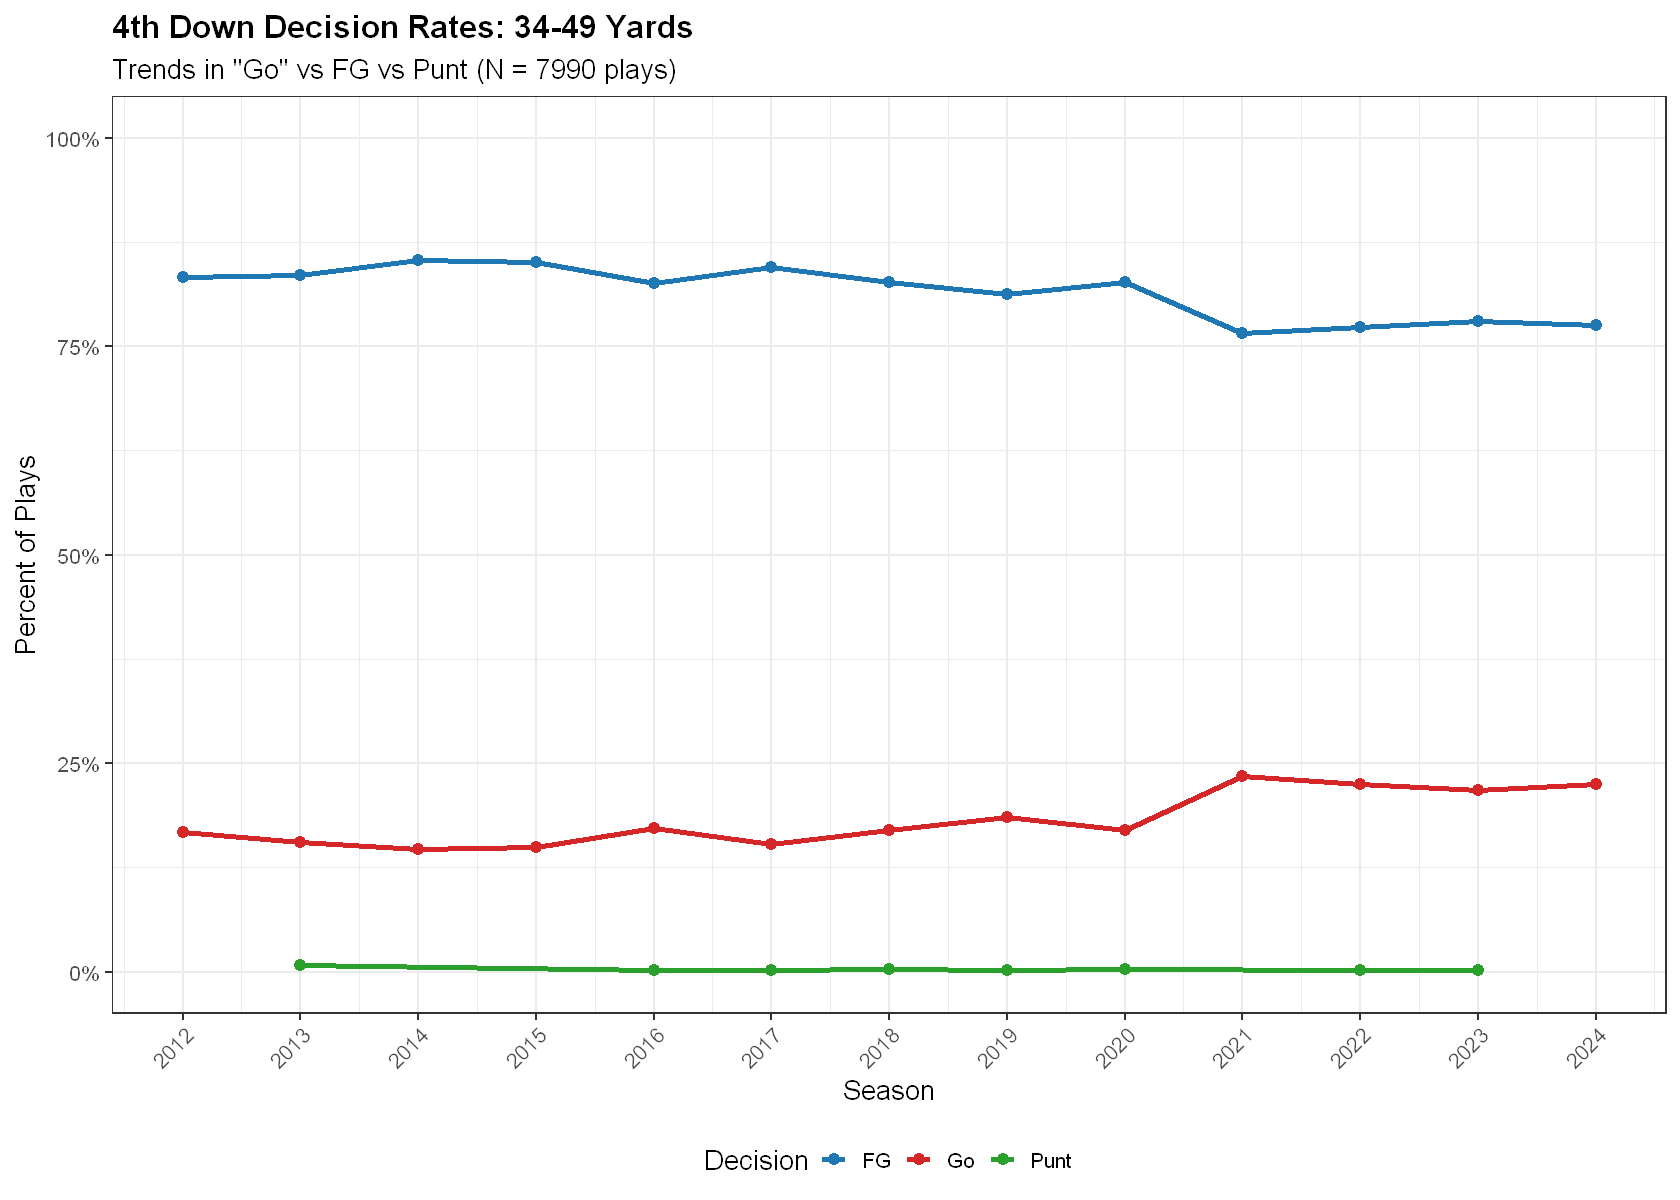

In [29]:
# ==============================================================================
# 4th Down Decision Analysis by Specific Distance Buckets
# ==============================================================================

# 1. Directory Setup
reports_attempt_dir <- file.path(reports_dir, 'attempt_pi')
if (!dir.exists(reports_attempt_dir)) dir.create(reports_attempt_dir, recursive = TRUE, showWarnings = FALSE)
fig_dir <- file.path(reports_attempt_dir, 'figs')
if (!dir.exists(fig_dir)) dir.create(fig_dir, recursive = TRUE, showWarnings = FALSE)

# 2. Base Data Preparation
# - Filter for 4th down
# - Combine Pass/Run into "Go"
# - Exclude PATs
fg_base <- fg_all %>%
  dplyr::filter(is_pat == 0L, play_type_original %in% c('field_goal','pass','run','punt')) %>%
  dplyr::mutate(
    play_type = dplyr::case_when(
      play_type_original == 'field_goal' ~ 'FG',
      play_type_original %in% c('pass', 'run') ~ 'Go', # Combined Category
      play_type_original == 'punt' ~ 'Punt',
      TRUE ~ play_type_original
    )
  ) %>%
  dplyr::filter(!is.na(kick_distance))

# 3. Define Buckets
# List of lists containing the Label and the Filter Logic
buckets <- list(
  list(id = "50_65", label = "50-65 Yards", func = function(d) d >= 50 & d <= 65),
  list(id = "40_49", label = "40-49 Yards", func = function(d) d >= 40 & d <= 49),
  list(id = "30_39", label = "30-39 Yards", func = function(d) d >= 30 & d <= 39),
  list(id = "18_29", label = "18-29 Yards", func = function(d) d >= 18 & d <= 29),
  list(id = "34_49", label = "34-49 Yards", func = function(d) d >= 34 & d <= 49)
)

# 4. Loop and Generate 4 Separate Plots
cat("Generating decision plots for distance buckets...\n")

# Set width to 14 inches for wide display in notebook
options(repr.plot.width = 14, repr.plot.height = 10)

for (b in buckets) {
  
  # --- A. Filter Data for Bucket ---
  bucket_data <- fg_base %>%
    dplyr::filter(b$func(kick_distance))
  
  # --- B. Calculate Rates ---
  rates <- bucket_data %>%
    dplyr::group_by(season, play_type) %>%
    dplyr::summarise(n = dplyr::n(), .groups = 'drop') %>%
    dplyr::group_by(season) %>%
    dplyr::mutate(total = sum(n), pct = n / total) %>%
    dplyr::ungroup()
  
  # --- C. Plot ---
  p <- ggplot2::ggplot(rates, ggplot2::aes(x = season, y = pct, colour = play_type, group = play_type)) +
    ggplot2::geom_line(linewidth = 1.5) +
    ggplot2::geom_point(size = 3) +
    ggplot2::scale_x_continuous(breaks = sort(unique(rates$season))) +
    ggplot2::scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
    ggplot2::scale_color_manual(values = c("FG" = "#1f77b4", "Go" = "#d62728", "Punt" = "#2ca02c")) +
    ggplot2::labs(
      title = paste0('4th Down Decision Rates: ', b$label),
      subtitle = paste0('Trends in "Go" vs FG vs Punt (N = ', sum(rates$n), ' plays)'),
      x = 'Season', y = 'Percent of Plays', colour = 'Decision'
    ) +
    ggplot2::theme_bw(base_size = 16) + # Increased font size
    ggplot2::theme(
      legend.position = 'bottom',
      plot.title = ggplot2::element_text(face = "bold"),
      axis.text.x = ggplot2::element_text(angle = 45, hjust = 1)
    )
  
  # --- D. Save ---
  filename <- paste0('decision_rates_bucket_', b$id, '.png')
  # Saving wide format (10x10)
  ggplot2::ggsave(filename = file.path(fig_dir, filename), plot = p, width = 10, height = 10)
  
  # Print to notebook
  print(p)
}


--- Season Statistics with Margins of Error ---
# A tibble: 13 × 13
   season n_kicks avg_distance sd_distance se_distance moe_distance make_pct
    <dbl>   <int>        <dbl>       <dbl>       <dbl>        <dbl>    <dbl>
 1   2012    1052         37.7        10.2       0.314        0.616    0.841
 2   2013    1042         37.5        10.2       0.317        0.622    0.866
 3   2014    1023         37.7        10.3       0.323        0.634    0.841
 4   2015    1033         38.1        10.3       0.319        0.626    0.849
 5   2016    1050         37.7        10.2       0.315        0.617    0.848
 6   2017    1065         38.2        10.1       0.310        0.608    0.843
 7   2018     989         38.6        10.0       0.318        0.623    0.844
 8   2019    1018         38.1        10.1       0.316        0.619    0.818
 9   2020    1015         38.9        10.4       0.326        0.639    0.846
10   2021    1076         38.6        10.3       0.314        0.616    0.853
11   20

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


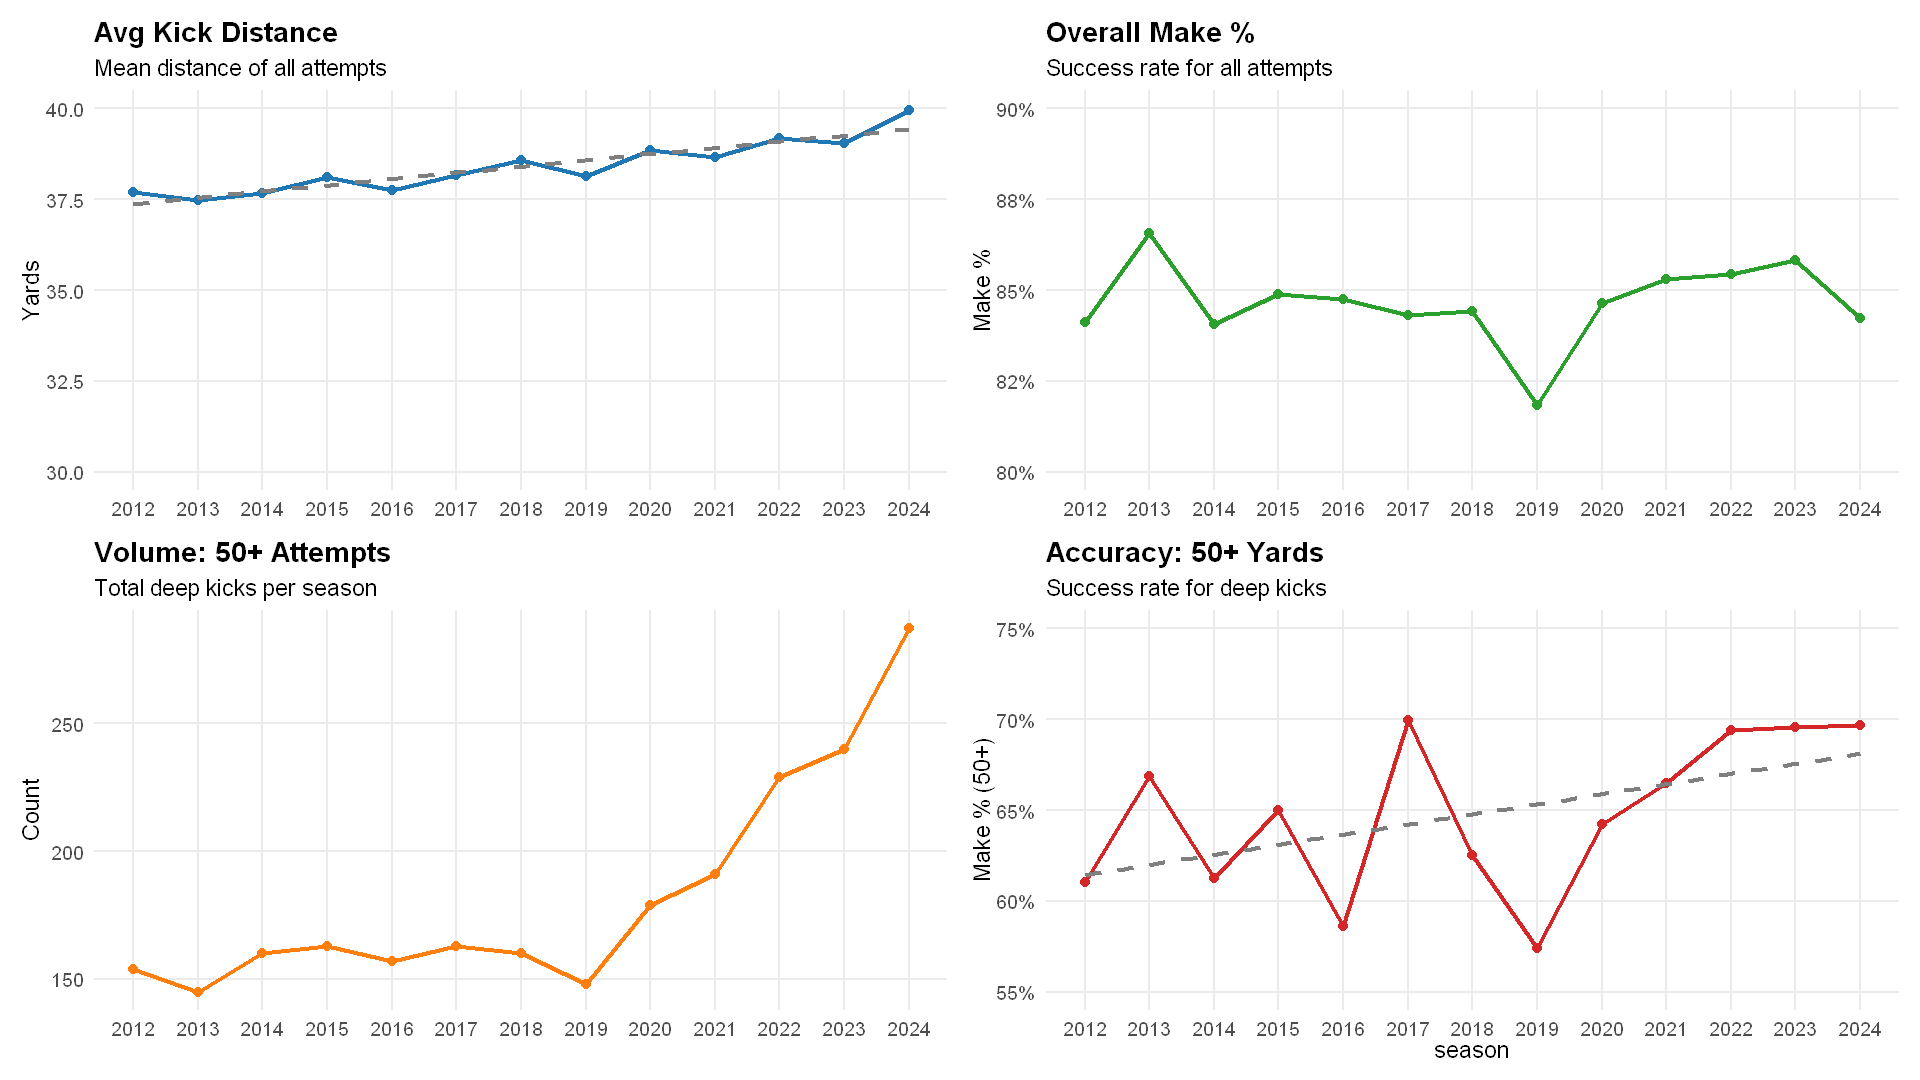

In [30]:
# ==============================================================================
# 1. Data Preparation & Aggregation
# ==============================================================================

# Filter for Field Goals only (exclude PATs)
fg_trends_data <- fg_all %>%
  dplyr::filter(play_type_original == 'field_goal', is_pat == 0) %>%
  dplyr::filter(!is.na(kick_distance), !is.na(kick_made))

# Calculate Season Stats with Error Margins
season_stats <- fg_trends_data %>%
  dplyr::group_by(season) %>%
  dplyr::summarise(
    n_kicks = dplyr::n(),
    
    # Metric 1: Average Distance
    avg_distance = mean(kick_distance, na.rm = TRUE),
    sd_distance = sd(kick_distance, na.rm = TRUE),
    se_distance = sd_distance / sqrt(n_kicks),
    moe_distance = 1.96 * se_distance,
    
    # Metric 2: Overall Make %
    make_pct = mean(kick_made, na.rm = TRUE),
    se_make = sqrt((make_pct * (1 - make_pct)) / n_kicks),
    moe_make = 1.96 * se_make,
    
    # Metric 3: Make % for 50+ Yards
    n_50_plus = sum(kick_distance >= 50, na.rm = TRUE),
    make_pct_50_plus = mean(kick_made[kick_distance >= 50], na.rm = TRUE),
    se_make_50 = sqrt((make_pct_50_plus * (1 - make_pct_50_plus)) / n_50_plus),
    moe_make_50 = 1.96 * se_make_50,
    
    .groups = "drop"
  )

cat("\n--- Season Statistics with Margins of Error ---\n")
print(season_stats)

# ==============================================================================
# 2. Plotting
# ==============================================================================

# Shared Theme
my_theme <- theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title.x = element_blank(),
    panel.grid.minor = element_blank()
  )

# --- Plot 1: Average Kicking Distance (30-40y Range) ---
p1 <- ggplot(season_stats, aes(x = season, y = avg_distance)) +
  geom_line(color = "#1f77b4", size = 1.2) +
  geom_point(color = "#1f77b4", size = 2.5) +
  #geom_errorbar(aes(ymin = avg_distance - moe_distance, ymax = avg_distance + moe_distance), 
  #              width = 0.2, color = "#1f77b4", alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE, linetype = "dashed", color = "grey50", alpha = 0.5) +
  scale_x_continuous(breaks = unique(season_stats$season)) +
  # Requested Range: 30-40
  coord_cartesian(ylim = c(30, 40)) + 
  labs(
    title = "Avg Kick Distance",
    subtitle = "Mean distance of all attempts",
    y = "Yards"
  ) +
  my_theme

# --- Plot 2: Overall Make Percentage (80-90% Range) ---
p2 <- ggplot(season_stats, aes(x = season, y = make_pct)) +
  geom_line(color = "#2ca02c", size = 1.2) +
  geom_point(color = "#2ca02c", size = 2.5) +
  #geom_errorbar(aes(ymin = make_pct - moe_make, ymax = make_pct + moe_make), 
  #              width = 0.2, color = "#2ca02c", alpha = 0.7) +
  scale_x_continuous(breaks = unique(season_stats$season)) +
  # Requested Range: 80-90%
  coord_cartesian(ylim = c(0.80, 0.90)) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title = "Overall Make %",
    subtitle = "Success rate for all attempts",
    y = "Make %"
  ) +
  my_theme

# --- Plot 3: Kicks Attempted from 50+ Yards (Count) ---
p3 <- ggplot(season_stats, aes(x = season, y = n_50_plus)) +
  geom_line(color = "#ff7f0e", size = 1.2) +
  geom_point(color = "#ff7f0e", size = 2.5) +
  scale_x_continuous(breaks = unique(season_stats$season)) +
  labs(
    title = "Volume: 50+ Attempts",
    subtitle = "Total deep kicks per season",
    y = "Count"
  ) +
  my_theme

# --- Plot 4: Make Percentage from 50+ Yards (55-70% Range) ---
p4 <- ggplot(season_stats, aes(x = season, y = make_pct_50_plus)) +
  geom_line(color = "#d62728", size = 1.2) +
  geom_point(color = "#d62728", size = 2.5) +
  #geom_errorbar(aes(ymin = make_pct_50_plus - moe_make_50, ymax = make_pct_50_plus + moe_make_50), 
  #              width = 0.2, color = "#d62728", alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE, linetype = "dashed", color = "grey50", alpha = 0.5) +
  scale_x_continuous(breaks = unique(season_stats$season)) +
  # Requested Range: 55-70%
  coord_cartesian(ylim = c(0.55, 0.75)) + # Extended slightly to 0.75 to capture upper CIs
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title = "Accuracy: 50+ Yards",
    subtitle = "Success rate for deep kicks",
    y = "Make % (50+)"
  ) +
  my_theme +
  theme(axis.title.x = element_text())

# ==============================================================================
# 3. Display & Save
# ==============================================================================

# Combine plots in a grid (2x2)
combined_plot <- (p1 + p2) / (p3 + p4)

# Set display options
options(repr.plot.width = 16, repr.plot.height = 9)
print(combined_plot)

# Save
if(exists("reports_dir")) {
  ggsave(filename = file.path(reports_dir, "season_kicking_trends_detailed.png"), 
         plot = combined_plot, width = 12, height = 10)
}

# A tibble: 2 × 2
  season mean_dist
  <fct>      <dbl>
1 2015        38.1
2 2024        39.9


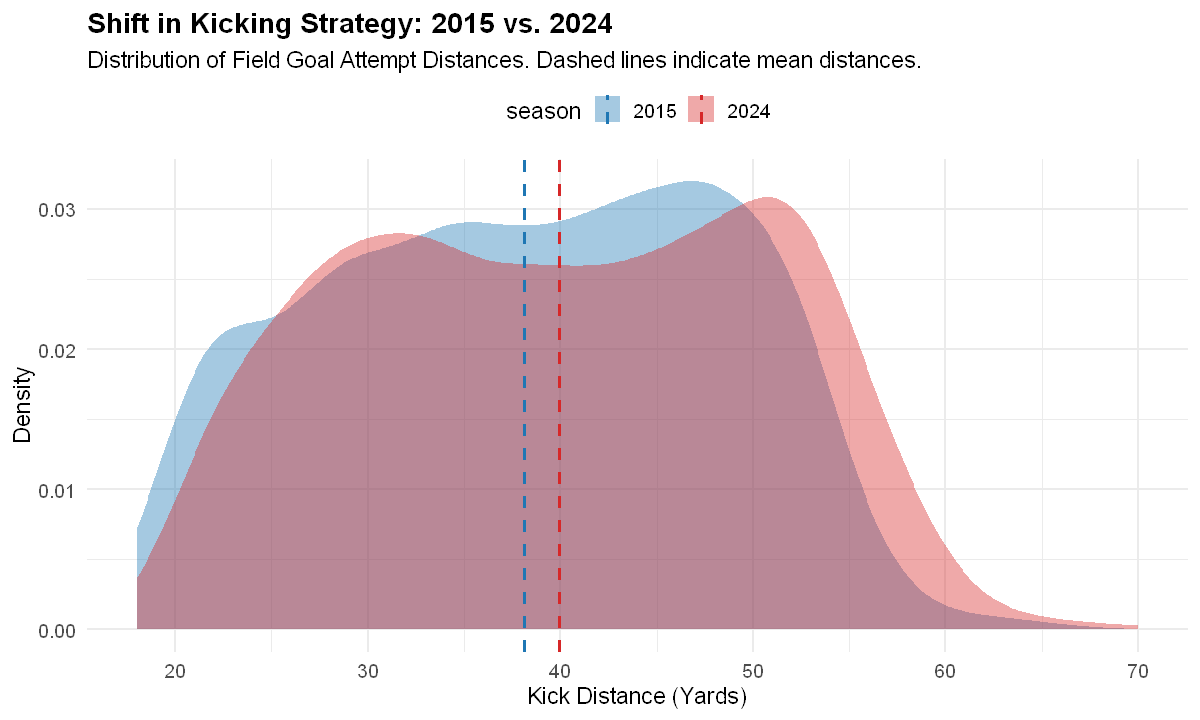

In [33]:

# 1. Prepare Data
# Filter for Field Goals in the specific target seasons
dist_comp_data <- fg_all %>%
  dplyr::filter(
    play_type_original == 'field_goal',
    is_pat == 0, # Exclude PATs
    season %in% c(2015, 2024),
    !is.na(kick_distance)
  ) %>%
  dplyr::mutate(season = factor(season)) # Make season a factor for plotting

# 2. Calculate Means for Annotation
season_means <- dist_comp_data %>%
  group_by(season) %>%
  summarise(mean_dist = mean(kick_distance), .groups = "drop")

print(season_means)

# 3. Generate Plot
p_dist_comp <- ggplot(dist_comp_data, aes(x = kick_distance, fill = season)) +
  # Density curves with transparency
  geom_density(alpha = 0.4, color = NA) +
  # Add mean lines
  geom_vline(data = season_means, aes(xintercept = mean_dist, color = season), 
             linetype = "dashed", size = 1, show.legend = TRUE) +
  # Custom colors
  scale_fill_manual(values = c("2015" = "#1f77b4", "2024" = "#d62728")) +
  scale_color_manual(values = c("2015" = "#1f77b4", "2024" = "#d62728")) +
  # Formatting
  labs(
    title = "Shift in Kicking Strategy: 2015 vs. 2024",
    subtitle = "Distribution of Field Goal Attempt Distances. Dashed lines indicate mean distances.",
    x = "Kick Distance (Yards)",
    y = "Density"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    plot.title = element_text(face = "bold")
  )

# 4. Display & Save
options(repr.plot.width = 10, repr.plot.height = 6)
print(p_dist_comp)

if(exists("reports_dir")) {
  ggsave(filename = file.path(reports_dir, "kick_distance_distribution_15vs24.png"), 
         plot = p_dist_comp, width = 10, height = 6)
}

In [24]:

# 1. Prepare Data
# Filter for the years of interest
anim_data <- fg_all %>%
  dplyr::filter(
    play_type_original == 'field_goal',
    is_pat == 0,
    season >= 2015,
    season <= 2024,
    !is.na(kick_distance)
  ) %>%
  dplyr::mutate(season = as.integer(season))

# 2. Create the Base Plot
# We use geom_density to show the shape of the distribution
p_anim <- ggplot(anim_data, aes(x = kick_distance)) +
  # Static background shadow (optional: shows the overall average for context)
  geom_density(data = anim_data %>% select(-season), 
               aes(x = kick_distance), 
               fill = "grey", alpha = 0.2, color = NA) +
  # The moving distribution
  geom_density(fill = "#1f77b4", alpha = 0.7, color = "black") +
  geom_vline(aes(xintercept = mean(kick_distance)), linetype = "dashed") +
  scale_x_continuous(limits = c(15, 65), breaks = seq(20, 60, 10)) +
  labs(
    title = "Evolution of Kick Distance: {closest_state}",
    subtitle = "Grey = 10-Year Average | Blue = Current Season",
    x = "Kick Distance (Yards)",
    y = "Density"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(face = "bold", size = 20),
    panel.grid.minor = element_blank()
  )

# 3. Animate
# transition_states: Splits the data by 'season' and tweens between them
anim <- p_anim + 
  transition_states(season, transition_length = 2, state_length = 1) +
  ease_aes('cubic-in-out') # Smooths the transition

# 4. Render and Save
# Adjust 'fps' and 'duration' to control speed
animate(anim, renderer = gifski_renderer(), height = 600, width = 800, fps = 20, duration = 10)

# Save to file
if(exists("reports_dir")) {
  anim_save(file.path(reports_dir, "kick_distance_evolution_15_24.gif"))
}

Warning message:
"Removed 8 rows containing non-finite outside the scale range
(`stat_density()`)."
Warning message:
"Removed 8 rows containing non-finite outside the scale range
(`stat_density()`)."


In [24]:
# Construct B-spline basis for kick_distance as in ref_modeling
bs_X <- splines2::bSpline(
  x = decision$kick_distance,
  knots = c(28,38,48,58),
  degree = 3,
  intercept = FALSE,
  Boundary.knots = c(18,70)
)
colnames(bs_X) <- paste0('bs_', seq_len(ncol(bs_X)))

# Time spline on game_seconds_remaining (natural cubic)
ns_time <- splines::ns(decision$game_seconds_remaining, df = 4)
colnames(ns_time) <- paste0('nst_', seq_len(ncol(ns_time)))

# Bind base design
X <- cbind(decision, as.data.frame(bs_X), as.data.frame(ns_time))

# assume decision already has quarter_seconds_remaining and qtr (or qtr equivalent)
# 1) Quarter-time features
X$quarter_sec <- as.numeric(ifelse('quarter_seconds_remaining' %in% names(X), X$quarter_seconds_remaining,
                                   ifelse('quarter_seconds_remaining' %in% names(decision), decision$quarter_seconds_remaining, NA_real_)))

# safe log transform: log(1 + seconds left in quarter)
X$log_qtr_time <- log1p(pmax(X$quarter_sec, 0))

# 2) Quarter flags (2nd and 4th)
# If your 'qtr' variable is named differently, adjust accordingly
X$q2_flag <- as.integer(as.integer(X$qtr) == 2)
X$q4_flag <- as.integer(as.integer(X$qtr) == 4)

# 3) Quarter-specific time terms (explicit interaction columns)
X$q2_log_time <- X$q2_flag * X$log_qtr_time
X$q4_log_time <- X$q4_flag * X$log_qtr_time

# 4) Interactions between score flags and quarter-log-time
score_vars <- c('go_ahead', 'one_score_down', 'to_tie', 'extend_lead', 'two_score_down')

# create named interaction column strings to add to base_terms (if you prefer formula-level interactions you can skip creating columns)
score_q2_interacts <- paste0(score_vars, ':q2_log_time')  # e.g. "go_ahead:q2_log_time"
score_q4_interacts <- paste0(score_vars, ':q4_log_time')

# If you prefer concrete columns (safer if you want to check numeric stability), you can also materialize them:
for (sv in score_vars) {
  if (sv %in% names(X)) {
    X[[paste0(sv, '_x_q2_log')]] <- X[[sv]] * X$q2_log_time
    X[[paste0(sv, '_x_q4_log')]] <- X[[sv]] * X$q4_log_time
  } else {
    # create zero/NA column to keep shapes consistent in case of missing flags
    X[[paste0(sv, '_x_q2_log')]] <- NA_real_
    X[[paste0(sv, '_x_q4_log')]] <- NA_real_
  }
}


# NOTE: We intentionally do NOT create bs * wind/temp interaction columns here.
# Those interactions were removed per request to simplify base terms.

# Rolling-origin OOF: train on seasons <= (s-1), predict s, starting s = 2015 (data back to 2012)
stopifnot('season' %in% names(X))
SEASONS_ALL <- sort(unique(X$season))
SEASONS_OOF <- SEASONS_ALL[SEASONS_ALL >= 2015]

# Prepare model formula components
bs_terms <- paste0('bs_', seq_len(ncol(bs_X)))
ns_t_terms <- paste0('nst_', seq_len(ncol(ns_time)))

# keep numeric season for indexing and factor season for modeling
X$season_num <- as.integer(X$season)
X$season <- factor(X$season_num)

base_terms <- c(
  bs_terms,
  ns_t_terms,
  'wind_z','temp_z','ydstogo', 'leverage_rules',
  'indoors','is_turf','high_altitude',
  'go_ahead', 'one_score_down', 'to_tie', 'extend_lead', 'two_score_down'
)


# ensure action is a factor for multinomial modeling (levels: go_for_it, punt, FG)
if (!'action' %in% names(X)) X$action <- ifelse(X$attempt_fg == 1, 'FG', 'go_for_it')
X$action <- factor(X$action, levels = c('go_for_it','punt','FG'))

# Multinomial model formula (action: go_for_it, punt, FG)
form_str_multi <- paste('action ~', paste(unique(base_terms), collapse = ' + '))
form_multinom <- as.formula(form_str_multi)

In [25]:
# Helper: Effective Sample Size
effective_sample_size <- function(w) {
  w <- w[is.finite(w)]
  if (!length(w)) return(NA_real_)
  (sum(w)^2) / sum(w^2)
}

all_preds    <- list()
metrics_rows <- list()

for (s in SEASONS_OOF) {
  window <- 3L
  start_season   <- max(min(SEASONS_ALL), s - window)
  train_seasons  <- seq(start_season, s - 1)
  train_idx <- which(X$season_num %in% train_seasons)
  test_idx  <- which(X$season_num == s)
  if (length(train_idx) < 100 || length(test_idx) == 0) next

  train <- X[train_idx, , drop = FALSE]
  test  <- X[test_idx,  , drop = FALSE]

  # --- Fit multinomial (action ~ ...)
  m_multi <- tryCatch(nnet::multinom(form_multinom, data = train, trace = FALSE),
                      error = function(e) NULL)

  # --- Predict FG probability on test
  p_multi <- rep(NA_real_, nrow(test))
  preds_multi <- NULL
  if (!is.null(m_multi)) {
    preds_multi <- tryCatch(predict(m_multi, newdata = test, type = "probs"),
                            error = function(e) NULL)
    if (!is.null(preds_multi) && "FG" %in% colnames(preds_multi)) {
      p_multi <- as.numeric(preds_multi[, "FG"])
    }
  }

  # --- Binary truth for FG attempt
  y_bin <- test$attempt_fg

  # --- Attempt model metrics (unweighted)
  auc_multi     <- tryCatch({ pROC::auc(y_bin, p_multi) |> as.numeric() }, error = function(e) NA_real_)
  brier_multi   <- brier(y_bin, p_multi)
  logloss_multi <- logloss(y_bin, p_multi)

  # ================== IPW (stabilized; UNTRIMMED) ==================
  # Numerically safe clamp for probabilities (prevents Inf/NaN weights only)
  # This is NOT "capping weights"—it just avoids divide-by-zero.
  eps <- .Machine$double.eps^0.5  # ~1e-8 on most systems
  p_clip_multi <- pmin(pmax(p_multi, eps), 1 - eps)

  # Stabilizer = prevalence in TRAIN window
  target_multi <- mean(train$attempt_fg, na.rm = TRUE)

  # Raw stabilized IPW (linear, positive)
  w_multi_raw <- ifelse(
    y_bin == 1L,
    target_multi / p_clip_multi,
    (1 - target_multi) / (1 - p_clip_multi)
  )

  # No trimming (as requested)
  w_multi_trim <- w_multi_raw   # keep raw

  # Hajek normalization (mean weight = 1 within this test fold)
  w_multi_hajek <- w_multi_trim / mean(w_multi_trim, na.rm = TRUE)

  # ESS diagnostics (all rows + A=1 rows that feed outcome model)
  ess_raw_all    <- effective_sample_size(w_multi_raw)
  ess_hajek_all  <- effective_sample_size(w_multi_hajek)

  a1 <- which(y_bin == 1L)
  ess_raw_A1    <- effective_sample_size(w_multi_raw[a1])
  ess_hajek_A1  <- effective_sample_size(w_multi_hajek[a1])

  # For quick tails debugging later (optional)
  w_multi_log <- log1p(w_multi_trim)
  # ================================================================

  # --- Predicted action label (argmax)
  act_pred <- if (!is.null(preds_multi)) tryCatch({
    apply(preds_multi, 1, function(row) {
      cols <- colnames(preds_multi); cols[which.max(row)]
    })
  }, error = function(e) rep(NA_character_, nrow(test))) else rep(NA_character_, nrow(test))

  # --- Collect per-row outputs
  fold_preds <- tibble::tibble(
    season = s,
    game_id = test$game_id,
    play_id = test$play_id,
    attempt_fg = y_bin,
    action_actual = as.character(test$action),
    action_pred   = as.character(act_pred),
    p_hat_multinom = p_multi,
    p_hat_clip_multinom = p_clip_multi,
    p_target_multinom = target_multi,
    weight_multinom_raw   = w_multi_raw,
    weight_multinom_hajek = w_multi_hajek,  # <-- use THIS in downstream success model (weights=)
    weight_multinom_log   = w_multi_log
  )
  all_preds[[as.character(s)]] <- fold_preds

  # --- Record metrics (+ ESS diagnostics)
  metrics_rows[[paste0("multinom_", s)]] <- tibble::tibble(
    season = s,
    model  = "multinom",
    auc    = auc_multi,
    brier  = brier_multi,
    logloss= logloss_multi,
    aic = NA_real_,
    bic = NA_real_,
    ess_all_raw   = ess_raw_all,
    ess_all_hajek = ess_hajek_all,
    ess_A1_raw    = ess_raw_A1,
    ess_A1_hajek  = ess_hajek_A1
  )
}

# Bind fold-level predictions
preds_oof <- dplyr::bind_rows(all_preds)

# Make join keys character to avoid mismatches
preds_oof <- preds_oof %>%
  dplyr::mutate(game_id = as.character(game_id), play_id = as.character(play_id))

# Attach auxiliary columns from X (if present)
if (all(c("game_id","play_id") %in% names(X))) {
  ctx <- X %>%
    dplyr::select(dplyr::any_of(c(
      "game_id","play_id","kick_distance","kick_result",
      "game_seconds_remaining","score_differential","ydstogo"
    ))) %>%
    dplyr::mutate(game_id = as.character(game_id), play_id = as.character(play_id)) %>%
    dplyr::distinct(game_id, play_id, .keep_all = TRUE)
  preds_oof <- preds_oof %>% dplyr::left_join(ctx, by = c("game_id","play_id"))
}

# Guarantee presence of requested columns (fill NA if absent)
req_cols <- c("kick_distance","kick_result","game_seconds_remaining","score_differential")
for (col in req_cols) if (!col %in% names(preds_oof)) preds_oof[[col]] <- NA

metrics_oof <- dplyr::bind_rows(metrics_rows)

# Persist outputs
readr::write_csv(preds_oof, file.path(reports_attempt_dir, "attempt_pi_oof_predictions.csv"))
readr::write_csv(metrics_oof, file.path(reports_attempt_dir, "attempt_pi_metrics_by_season.csv"))

# Calibration summary by distance & time bins (using multinomial FG prob)
calib <- preds_oof %>%
  dplyr::mutate(
    dist_bin = cut(kick_distance, breaks = seq(15, 70, 5), include.lowest = TRUE, right = FALSE),
    time_bin = cut(game_seconds_remaining, breaks = c(0,60,120,300,900,1800,3600),
                   include.lowest = TRUE, right = FALSE)
  ) %>%
  dplyr::group_by(dist_bin, time_bin) %>%
  dplyr::summarise(
    n   = dplyr::n(),
    obs = mean(attempt_fg, na.rm = TRUE),
    est = mean(p_hat_multinom, na.rm = TRUE),
    abs_err = abs(est - obs),
    .groups = "drop"
  )

readr::write_csv(calib, file.path(reports_attempt_dir, "attempt_pi_calibration.csv"))

list(head(metrics_oof, 10), head(calib, 10))


Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



season,model,auc,brier,logloss,aic,bic,ess_all_raw,ess_all_hajek,ess_A1_raw,ess_A1_hajek
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2015,multinom,0.9603138,0.07633518,0.2495578,NA,NA,181.217759,181.217759,63.348108,63.348108
2016,multinom,0.9557895,0.08015524,0.2603282,NA,NA,117.143476,117.143476,125.508456,125.508456
2017,multinom,0.9567478,0.08000588,0.2613217,NA,NA,123.948475,123.948475,48.894390,48.894390
2018,multinom,0.9569950,0.08119374,0.2614976,NA,NA,158.955553,158.955553,63.196431,63.196431
2019,multinom,0.9507547,0.08905035,0.2826874,NA,NA,268.915789,268.915789,93.156610,93.156610
2020,multinom,0.9440797,0.09478269,0.3011590,NA,NA,1.519772,1.519772,1.223993,1.223993
2021,multinom,0.9378135,0.10011864,0.3151768,NA,NA,215.615709,215.615709,120.106459,120.106459
2022,multinom,0.9376087,0.10097724,0.3142194,NA,NA,215.700066,215.700066,196.123295,196.123295
2023,multinom,0.9431689,0.09538734,0.3006712,NA,NA,392.076204,392.076204,239.654471,239.654471


In [26]:
# ================== CLIP p̂, BUILD IPW, HÁJEK, 3*SD CAP, RE-HÁJEK, DIAGNOSTICS ==================
clip_min <- 0.02
clip_max <- 0.98

stopifnot(all(c("p_hat_multinom","p_target_multinom","attempt_fg") %in% names(preds_oof)))

ess <- function(w) {
  w <- w[is.finite(w)]
  if (!length(w)) return(NA_real_)
  (sum(w)^2) / sum(w^2)
}

# 1) Clip propensities and compute stabilized IPW (raw)
preds_oof <- preds_oof %>%
  dplyr::mutate(
    p_hat_attempt_clipped = pmin(pmax(p_hat_multinom, clip_min), clip_max),
    w_ipw_raw = ifelse(
      attempt_fg == 1L,
      p_target_multinom / p_hat_attempt_clipped,
      (1 - p_target_multinom) / (1 - p_hat_attempt_clipped)
    )
  )

# 2) Hájek-normalize within season (clip-only baseline)
preds_oof <- preds_oof %>%
  dplyr::group_by(season) %>%
  dplyr::mutate(
    w_clip_hajek = w_ipw_raw / mean(w_ipw_raw, na.rm = TRUE)  # mean ≈ 1 per season
  ) %>%
  dplyr::ungroup()

# 3) Compute 3*SD cap on the clip-hajek weights, apply, then RE-Hájek
preds_oof <- preds_oof %>%
  dplyr::group_by(season) %>%
  dplyr::mutate(
    w_mean = mean(w_clip_hajek, na.rm = TRUE),   # ~1
    w_sd   = sd(w_clip_hajek,   na.rm = TRUE),
    w_cap  = w_mean + 3*w_sd,
    w_clip_hajek_capped = pmin(w_clip_hajek, w_cap),
    # RE-Hájek to restore mean=1 after capping
    w_ipw_final = w_clip_hajek_capped / mean(w_clip_hajek_capped, na.rm = TRUE)
  ) %>%
  dplyr::ungroup() %>%
  dplyr::select(-w_mean, -w_sd, -w_cap)

# 4) Diagnostics (AFTER re-Hájek)
diag_overall <- dplyr::bind_rows(
  preds_oof %>% dplyr::summarise(
    which="clip_only",
    n = dplyr::n(),
    min  = min(w_clip_hajek, na.rm=TRUE),
    mean = mean(w_clip_hajek, na.rm=TRUE),
    sd   = sd(w_clip_hajek,   na.rm=TRUE),
    p99  = quantile(w_clip_hajek, 0.99, na.rm=TRUE),
    max  = max(w_clip_hajek, na.rm=TRUE),
    ess  = ess(w_clip_hajek),
    ess_frac = ess / n
  ),
  preds_oof %>% dplyr::summarise(
    which="clip_then_3sd_rehajek",
    n = dplyr::n(),
    min  = min(w_ipw_final, na.rm=TRUE),
    mean = mean(w_ipw_final, na.rm=TRUE),
    sd   = sd(w_ipw_final,   na.rm=TRUE),
    p99  = quantile(w_ipw_final, 0.99, na.rm=TRUE),
    max  = max(w_ipw_final, na.rm=TRUE),
    ess  = ess(w_ipw_final),
    ess_frac = ess / n
  )
)

diag_byA <- dplyr::bind_rows(
  preds_oof %>% dplyr::group_by(which="clip_only", attempt_fg) %>%
    dplyr::summarise(
      n   = dplyr::n(),
      ess = ess(w_clip_hajek),
      ess_frac = ess / n,
      p99 = quantile(w_clip_hajek, 0.99, na.rm=TRUE),
      max = max(w_clip_hajek, na.rm=TRUE),
      .groups="drop"
    ),
  preds_oof %>% dplyr::group_by(which="clip_then_3sd_rehajek", attempt_fg) %>%
    dplyr::summarise(
      n   = dplyr::n(),
      ess = ess(w_ipw_final),
      ess_frac = ess / n,
      p99 = quantile(w_ipw_final, 0.99, na.rm=TRUE),
      max = max(w_ipw_final, na.rm=TRUE),
      .groups="drop"
    )
)

diag_by_dist <- preds_oof %>%
  dplyr::mutate(
    dist_bin = cut(kick_distance, breaks = seq(15, 70, 5),
                   include.lowest = TRUE, right = FALSE)
  ) %>%
  dplyr::group_by(dist_bin) %>%
  dplyr::summarise(
    n = dplyr::n(),
    ess_clip_only = ess(w_clip_hajek),
    ess_final     = ess(w_ipw_final),
    .groups="drop"
  )

# (Optional) Persist
# readr::write_csv(diag_overall, file.path(reports_attempt_dir, "attempt_ipw_diag_overall.csv"))
# readr::write_csv(diag_byA,     file.path(reports_attempt_dir, "attempt_ipw_diag_byA.csv"))
# readr::write_csv(diag_by_dist, file.path(reports_attempt_dir, "attempt_ipw_diag_by_dist.csv"))

list(diag_overall, diag_byA, diag_by_dist)


[[1]]
# A tibble: 2 × 9
  which                     n   min  mean    sd   p99   max   ess ess_frac
  <chr>                 <int> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>    <dbl>
1 clip_only             20605 0.524     1  1.92  7.85 30.7  4382.    0.213
2 clip_then_3sd_rehajek 20605 0.588     1  1.05  6.92  8.55 9812.    0.476

[[2]]
# A tibble: 4 × 7
  which                 attempt_fg     n   ess ess_frac   p99   max
  <chr>                      <int> <int> <dbl>    <dbl> <dbl> <dbl>
1 clip_only                      0  9981 2147.    0.215  9.15 28.1 
2 clip_only                      1 10624 2248.    0.212  6.18 30.7 
3 clip_then_3sd_rehajek          0  9981 4375.    0.438  7.39  8.55
4 clip_then_3sd_rehajek          1 10624 5670.    0.534  6.67  8.55

[[3]]
# A tibble: 11 × 4
   dist_bin     n ess_clip_only ess_final
   <fct>    <int>         <dbl>     <dbl>
 1 [15,20)    497          225.      279.
 2 [20,25)   1477          534.      756.
 3 [25,30)   1652          395.      779.
 4 [30,35)   1824          441.      872.
 5 [35,40)   1852          430.      866.
 6 [40,45)   1923          372.      864.
 7 [45,50)   2078          461.     1018.
 8 [50,55)   2174          988.     1358.
 9 [55,60)   2193          583.     1022.
10 [60,65)   2159          208.      766.
11 [65,70]   2776          469.     1966.

In [27]:
# Diagnostic: formula, coefficients, VIF, calibration by decile and score-group
try({
  message('Formula:'); print(form_str_multi)
  message('Num base terms: ', length(unique(base_terms)))

  # Re-fit on full X for inspection (safe try)
  full_fit <- tryCatch(nnet::multinom(form_multinom, data = X, trace = FALSE), error = function(e) { message('full fit failed: ', e$message); NULL })
  if (!is.null(full_fit)) {
    message('Coefficient summary (top magnitude per class):')
    coefs <- coef(full_fit)            # matrix classes x predictors
    # Convert to long table and show top absolute coeffs
    coef_tbl <- as.data.frame(coefs) %>%
      tibble::rownames_to_column('class') %>%
      tidyr::pivot_longer(-class, names_to = 'term', values_to = 'est') %>%
      dplyr::mutate(abs_est = abs(est)) %>%
      dplyr::arrange(dplyr::desc(abs_est))
    print(head(coef_tbl, 30))

    # VIF via a proxy linear model on the model matrix (multicollinearity check)
    if (!requireNamespace('car', quietly = TRUE)) install.packages('car')
    mm <- stats::model.matrix(as.formula(paste('attempt_fg ~', paste(unique(base_terms), collapse = ' + '))), data = X)
    lm_proxy <- tryCatch(stats::lm(X$attempt_fg ~ mm - 1), error = function(e) NULL)
    if (!is.null(lm_proxy)) {
      vif_vals <- tryCatch(car::vif(lm_proxy), error = function(e) { message('vif failed: ', e$message); NULL })
      if (!is.null(vif_vals)) {
        print(head(sort(vif_vals, decreasing = TRUE), 30))
      }
    }
  }

  # Calibration by decile (using preds_oof already produced)
  if (exists('preds_oof')) {
    preds_oof <- preds_oof %>% dplyr::mutate(p_hat = p_hat_multinom)
    preds_oof <- preds_oof %>% dplyr::mutate(decile = ntile(p_hat, 10))
    calib_dec <- preds_oof %>%
      dplyr::group_by(decile) %>%
      dplyr::summarise(n = dplyr::n(), obs = mean(attempt_fg, na.rm = TRUE), est = mean(p_hat, na.rm = TRUE), .groups = 'drop')
    print(calib_dec)

    # Calibration by decile × score flag (example: go_ahead)
    calib_group <- preds_oof %>%
      dplyr::group_by(decile, go_ahead) %>%
      dplyr::summarise(n = dplyr::n(), obs = mean(attempt_fg, na.rm = TRUE), est = mean(p_hat, na.rm = TRUE), .groups = 'drop')
    print(head(calib_group, 30))

    # quick calibration plot
    if (requireNamespace('ggplot2', quietly = TRUE)) {
      p_cal <- ggplot2::ggplot(calib_dec, ggplot2::aes(x = est, y = obs)) +
        ggplot2::geom_point() + ggplot2::geom_abline(slope = 1, intercept = 0, linetype = 'dashed', color = 'grey50') +
        ggplot2::labs(title = 'Calibration by decile', x = 'Estimated (mean decile)', y = 'Observed')
      print(p_cal)
    }
  }
}, silent = TRUE)

Formula:



[1] "action ~ bs_1 + bs_2 + bs_3 + bs_4 + bs_5 + bs_6 + bs_7 + nst_1 + nst_2 + nst_3 + nst_4 + wind_z + temp_z + ydstogo + leverage_rules + indoors + is_turf + high_altitude + go_ahead + one_score_down + to_tie + extend_lead + two_score_down"


Num base terms: 23

Coefficient summary (top magnitude per class):



# A tibble: 30 × 4
   class term              est abs_est
   <chr> <chr>           <dbl>   <dbl>
 1 punt  (Intercept)    -22.5    22.5 
 2 punt  bs_7            18.6    18.6 
 3 punt  bs_5            18.5    18.5 
 4 punt  bs_6            17.3    17.3 
 5 punt  bs_1            14.3    14.3 
 6 punt  bs_2           -13.9    13.9 
 7 punt  bs_4            11.9    11.9 
 8 punt  bs_3             9.85    9.85
 9 FG    (Intercept)     -7.18    7.18
10 FG    leverage_rules   5.66    5.66
# ℹ 20 more rows


Warning message in vif.default(lm_proxy):
"No intercept: vifs may not be sensible."
vif failed: model contains fewer than 2 terms



# A tibble: 10 × 4
   decile     n      obs      est
    <int> <int>    <dbl>    <dbl>
 1      1  2061 0.000970 0.000933
 2      2  2061 0.00776  0.00650 
 3      3  2061 0.0388   0.0392  
 4      4  2061 0.208    0.192   
 5      5  2061 0.490    0.476   
 6      6  2060 0.683    0.715   
 7      7  2060 0.828    0.859   
 8      8  2060 0.933    0.935   
 9      9  2060 0.978    0.973   
10     10  2060 0.990    0.993   


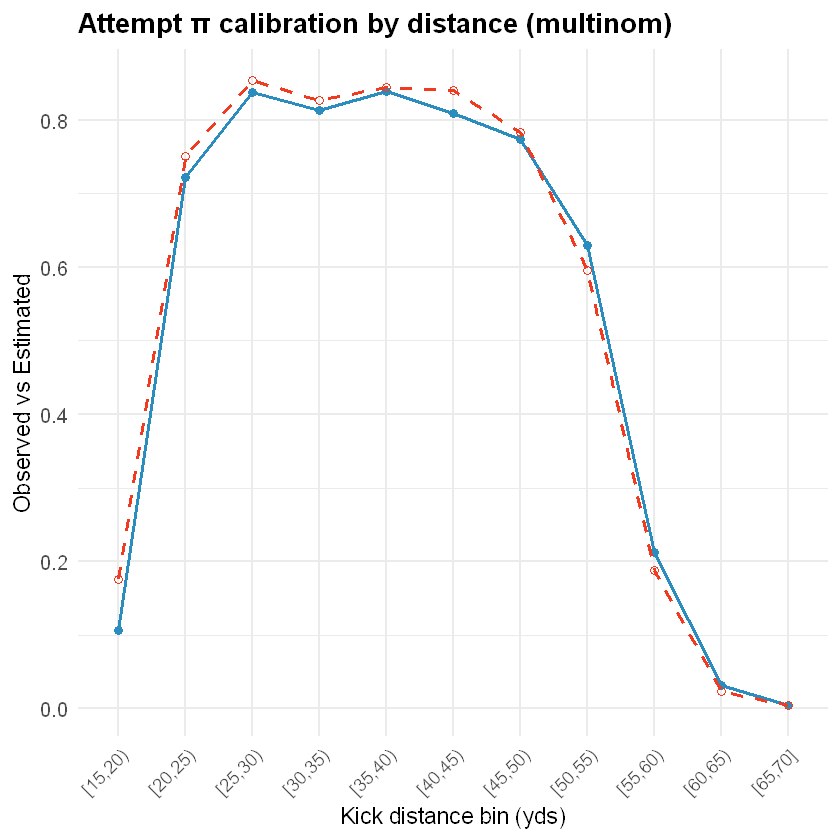

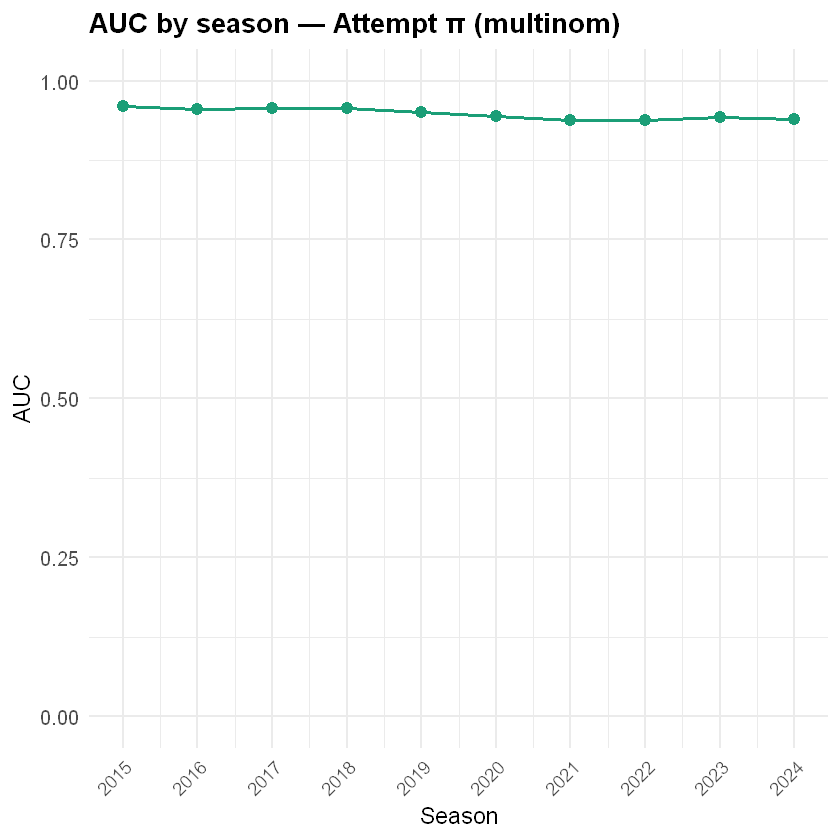

In [28]:
# Plots — Calibration (distance/time) and AUC by season (multinom only)
ensure_dir <- function(p) if (!dir.exists(p)) dir.create(p, recursive = TRUE, showWarnings = FALSE)
fig_dir <- file.path(reports_dir, 'attempt_pi', 'figs')
ensure_dir(fig_dir)

# Use preds_oof directly; it should already contain kick_distance and game_seconds_remaining
# Coerce numeric types and build safe bins; avoid re-joining X to prevent type-mismatch errors
cal_long <- preds_oof %>%
  dplyr::mutate(
    p_hat = p_hat_multinom,
    model = 'multinom',
    kd = as.numeric(kick_distance),
    tsec = as.numeric(game_seconds_remaining),
    # cut will return NA for NA inputs; it's safe once kd/tsec are numeric
    dist_bin = cut(kd, breaks = seq(15,70,5), include.lowest = TRUE, right = FALSE),
    time_bin = cut(tsec, breaks = c(0,60,120,300,900,1800,3600), include.lowest = TRUE, right = FALSE)
  )

# Ensure dist_bin/time_bin are factors with stable levels even if some are all NA
dist_levels <- if (!is.null(levels(cal_long$dist_bin))) levels(cal_long$dist_bin) else character(0)
time_levels <- if (!is.null(levels(cal_long$time_bin))) levels(cal_long$time_bin) else character(0)

# Summaries for calibration (multinom only)
dist_calib <- cal_long %>%
  dplyr::group_by(model, dist_bin) %>%
  dplyr::summarise(
    n = dplyr::n(),
    obs = mean(attempt_fg, na.rm = TRUE),
    est = mean(p_hat, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  dplyr::mutate(dist_bin = factor(dist_bin, levels = dist_levels))

time_calib <- cal_long %>%
  dplyr::group_by(model, time_bin) %>%
  dplyr::summarise(
    n = dplyr::n(),
    obs = mean(attempt_fg, na.rm = TRUE),
    est = mean(p_hat, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  dplyr::mutate(time_bin = factor(time_bin, levels = time_levels))

# Theme for readability
theme_readable <- ggplot2::theme_minimal(base_size = 14) +
  ggplot2::theme(
    axis.text.x = ggplot2::element_text(angle = 45, hjust = 1, size = 11),
    axis.text.y = ggplot2::element_text(size = 12),
    legend.position = 'right',
    legend.title = ggplot2::element_blank(),
    plot.title = ggplot2::element_text(size = 16, face = 'bold')
  )

# Combined distance calibration (observed solid, estimated dashed)
p_dist <- ggplot2::ggplot(dist_calib, ggplot2::aes(x = dist_bin, group = 1)) +
  ggplot2::geom_line(ggplot2::aes(y = obs), colour = '#2b8cbe', size = 1.1) +
  ggplot2::geom_point(ggplot2::aes(y = obs), colour = '#2b8cbe', size = 2) +
  ggplot2::geom_line(ggplot2::aes(y = est), colour = '#f03b20', linetype = "dashed", size = 1) +
  ggplot2::geom_point(ggplot2::aes(y = est), colour = '#f03b20', shape = 1, size = 2) +
  ggplot2::labs(title = 'Attempt π calibration by distance (multinom)', x = 'Kick distance bin (yds)', y = 'Observed vs Estimated') +
  theme_readable

# Faceted distance plot (single model)
p_dist_facet <- ggplot2::ggplot(dist_calib, ggplot2::aes(x = dist_bin, group = 1)) +
  ggplot2::geom_line(ggplot2::aes(y = obs), colour = '#2b8cbe', size = 1.1) +
  ggplot2::geom_point(ggplot2::aes(y = obs), colour = '#2b8cbe', size = 2) +
  ggplot2::geom_line(ggplot2::aes(y = est), colour = '#f03b20', linetype = 'dashed', size = 1) +
  ggplot2::geom_point(ggplot2::aes(y = est), colour = '#f03b20', shape = 1, size = 2) +
  ggplot2::labs(title = 'Attempt π calibration by distance (multinom — faceted)', x = 'Kick distance bin (yds)', y = 'Observed vs Estimated') +
  theme_readable

# Save high-res and vector versions
ggplot2::ggsave(filename = file.path(fig_dir, 'calibration_distance.png'), plot = p_dist, width = 12, height = 7, dpi = 300)
GG <- ggplot2::ggsave(filename = file.path(fig_dir, 'calibration_distance.pdf'), plot = p_dist, width = 12, height = 7)

ggplot2::ggsave(filename = file.path(fig_dir, 'calibration_distance_facet.png'), plot = p_dist_facet, width = 10, height = 8, dpi = 300)

# Print combined plot
p_dist

# Combined time calibration
p_time <- ggplot2::ggplot(time_calib, ggplot2::aes(x = time_bin, group = 1)) +
  ggplot2::geom_line(ggplot2::aes(y = obs), colour = '#2b8cbe', size = 1.1) +
  ggplot2::geom_point(ggplot2::aes(y = obs), colour = '#2b8cbe', size = 2) +
  ggplot2::geom_line(ggplot2::aes(y = est), colour = '#f03b20', linetype = "dashed", size = 1) +
  ggplot2::geom_point(ggplot2::aes(y = est), colour = '#f03b20', shape = 1, size = 2) +
  ggplot2::labs(title = 'Attempt π calibration by time (multinom)', x = 'Game seconds remaining (bins)', y = 'Observed vs Estimated') +
  theme_readable

# Faceted time plot
p_time_facet <- ggplot2::ggplot(time_calib, ggplot2::aes(x = time_bin, group = 1)) +
  ggplot2::geom_line(ggplot2::aes(y = obs), colour = '#2b8cbe', size = 1.1) +
  ggplot2::geom_point(ggplot2::aes(y = obs), colour = '#2b8cbe', size = 2) +
  ggplot2::geom_line(ggplot2::aes(y = est), colour = '#f03b20', linetype = 'dashed', size = 1) +
  ggplot2::geom_point(ggplot2::aes(y = est), colour = '#f03b20', shape = 1, size = 2) +
  ggplot2::labs(title = 'Attempt π calibration by time (multinom — faceted)', x = 'Game seconds remaining (bins)', y = 'Observed vs Estimated') +
  theme_readable

ggplot2::ggsave(filename = file.path(fig_dir, 'calibration_time.png'), plot = p_time, width = 12, height = 7, dpi = 300)
GG <- ggplot2::ggsave(filename = file.path(fig_dir, 'calibration_time_facet.png'), plot = p_time_facet, width = 10, height = 8, dpi = 300)

# AUC by season (multinom only)
auc_by_season <- metrics_oof %>% dplyr::filter(model == 'multinom') %>% dplyr::arrange(season)
p_auc <- ggplot2::ggplot(auc_by_season, ggplot2::aes(x = season, y = auc)) +
  ggplot2::geom_line(size = 1, colour = '#1b9e77') +
  ggplot2::geom_point(size = 3, colour = '#1b9e77') +
  ggplot2::scale_x_continuous(breaks = sort(unique(auc_by_season$season))) +
  ggplot2::scale_y_continuous(limits = c(0,1)) +
  ggplot2::labs(title = 'AUC by season — Attempt π (multinom)', x = 'Season', y = 'AUC') +
  theme_readable

ggplot2::ggsave(filename = file.path(fig_dir, 'auc_by_season.png'), plot = p_auc, width = 10, height = 5, dpi = 300)
GG <- ggplot2::ggsave(filename = file.path(fig_dir, 'auc_by_season.pdf'), plot = p_auc, width = 10, height = 5)

p_auc


In [29]:
# ================== FINAL WEIGHT DIAGNOSTICS & EXPORT (using w_ipw_final) ==================
options(scipen = 999)

# Sanity: ensure final weights exist
stopifnot("w_ipw_final" %in% names(preds_oof))


# ---------- Helper: ESS ----------
ess <- function(w) {
  w <- w[is.finite(w)]
  if (!length(w)) return(NA_real_)
  (sum(w)^2) / sum(w^2)
}

# ---------- Overall & by-group summaries (final weights) ----------
summary_overall <- preds_oof %>%
  dplyr::summarise(
    n    = dplyr::n(),
    min  = min(w_ipw_final, na.rm = TRUE),
    mean = mean(w_ipw_final, na.rm = TRUE),
    sd   = sd(w_ipw_final,   na.rm = TRUE),
    p95  = quantile(w_ipw_final, 0.95, na.rm = TRUE),
    p99  = quantile(w_ipw_final, 0.99, na.rm = TRUE),
    max  = max(w_ipw_final,  na.rm = TRUE),
    ess  = ess(w_ipw_final),
    ess_frac = ess / n
  )

summary_byA <- preds_oof %>%
  dplyr::group_by(action_actual) %>%
  dplyr::summarise(
    n    = dplyr::n(),
    mean = mean(w_ipw_final, na.rm=TRUE),
    sd   = sd(w_ipw_final,   na.rm=TRUE),
    p99  = quantile(w_ipw_final, 0.99, na.rm=TRUE),
    max  = max(w_ipw_final,  na.rm=TRUE),
    ess  = ess(w_ipw_final),
    ess_frac = ess / n,
    .groups = "drop"
  )

summary_by_dist <- preds_oof %>%
  dplyr::mutate(
    dist_bin = cut(kick_distance, breaks = seq(15, 70, 5),
                   include.lowest = TRUE, right = FALSE)
  ) %>%
  dplyr::group_by(dist_bin) %>%
  dplyr::summarise(
    n    = dplyr::n(),
    ess  = ess(w_ipw_final),
    ess_frac = ess / n,
    p99  = quantile(w_ipw_final, 0.99, na.rm=TRUE),
    max  = max(w_ipw_final,  na.rm=TRUE),
    .groups = "drop"
  )

# ---------- Top-5 plays per season by final weight ----------
top5_by_season <- preds_oof %>%
  dplyr::arrange(season, dplyr::desc(w_ipw_final)) %>%
  dplyr::group_by(season) %>%
  dplyr::slice_head(n = 5) %>%
  dplyr::ungroup() %>%
  dplyr::select(
    season, game_id, play_id,
    action_actual, action_pred,
    score_differential, ydstogo, kick_distance, game_seconds_remaining,
    p_hat_multinom, w_ipw_final
  )

# ---------- Plots: distributions for final weights ----------
ensure_dir <- function(p) if (!dir.exists(p)) dir.create(p, recursive = TRUE, showWarnings = FALSE)
ensure_dir(reports_attempt_dir)
fig_dir <- file.path(reports_attempt_dir, "figs"); ensure_dir(fig_dir)

plot_df <- preds_oof %>% dplyr::select(action_actual, w_ipw_final)

# Histogram (final Hajek weights)
p_hist_final <- ggplot2::ggplot(plot_df, ggplot2::aes(x = w_ipw_final)) +
  ggplot2::geom_histogram(bins = 60, colour = "white") +
  ggplot2::facet_wrap(~ action_actual, scales = "free_x") +
  ggplot2::labs(title = "Final stabilized IPW (clip→3SD cap→re-Hájek)",
                x = "Final Hájek weight (mean≈1 per season)", y = "Count") +
  ggplot2::theme_minimal(base_size = 12)

# Density of log1p(final) for tail shape
p_dens_final <- ggplot2::ggplot(plot_df %>% dplyr::mutate(lw = log1p(w_ipw_final)),
                                ggplot2::aes(x = lw)) +
  ggplot2::geom_density(adjust = 1) +
  ggplot2::facet_wrap(~ action_actual, scales = "free") +
  ggplot2::labs(title = "log1p(Final Hájek weight) density",
                x = "log1p(weight)", y = "Density") +
  ggplot2::theme_minimal(base_size = 12)

ggplot2::ggsave(file.path(fig_dir, "weight_hist_final.png"),  p_hist_final,  width = 12, height = 6, dpi = 200)
ggplot2::ggsave(file.path(fig_dir, "weight_density_log1p_final.png"), p_dens_final, width = 12, height = 6, dpi = 200)

# ---------- Save outputs ----------
# 1) Save the updated preds_oof with final weights
readr::write_csv(preds_oof, file.path(reports_attempt_dir, "attempt_pi_oof_predictions_final.csv"))

# 2) Save summaries and top-5 table
readr::write_csv(summary_overall,  file.path(reports_attempt_dir, "attempt_ipw_final_overall.csv"))
readr::write_csv(summary_byA,      file.path(reports_attempt_dir, "attempt_ipw_final_byA.csv"))
readr::write_csv(summary_by_dist,  file.path(reports_attempt_dir, "attempt_ipw_final_by_dist.csv"))
readr::write_csv(top5_by_season,   file.path(reports_attempt_dir, "attempt_pi_top5_by_season.csv"))

# ---------- Return a compact list for interactive runs ----------
list(
  summary_overall = summary_overall,
  summary_byA     = summary_byA,
  summary_by_dist = summary_by_dist,
  top5_by_season  = top5_by_season
)


$summary_overall
# A tibble: 1 × 9
      n   min  mean    sd   p95   p99   max   ess ess_frac
  <int> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>    <dbl>
1 20605 0.588     1  1.05  2.57  6.92  8.55 9812.    0.476

$summary_byA
# A tibble: 3 × 8
  action_actual     n  mean    sd   p99   max   ess ess_frac
  <chr>         <int> <dbl> <dbl> <dbl> <dbl> <dbl>    <dbl>
1 FG            10624 0.947 0.885  6.67  8.55 5670.    0.534
2 go_for_it      5053 1.42  1.56   7.91  8.55 2296.    0.454
3 punt           4928 0.686 0.383  2.11  8.06 3754.    0.762

$summary_by_dist
# A tibble: 11 × 6
   dist_bin     n   ess ess_frac   p99   max
   <fct>    <int> <dbl>    <dbl> <dbl> <dbl>
 1 [15,20)    497  279.    0.561 4.91   7.91
 2 [20,25)   1477  756.    0.512 6.92   8.55
 3 [25,30)   1652  779.    0.472 6.92   8.55
 4 [30,35)   1824  872.    0.478 7.38   8.55
 5 [35,40)   1852  866.    0.468 7.15   8.55
 6 [40,45)   1923  864.    0.449 7.62   8.55
 7 [45,50)   2078 1018.    0.490 7.39   8.55
 8 [50,55)   2174 1358.    0.624 5.37   8.55
 9 [55,60)   2193 1022.    0.466 7.39   8.55
10 [60,65)   2159  766.    0.355 7.72   8.55
11 [65,70]   2776 1966.    0.708 0.639  8.17

$top5_by_season
# A tibble: 50 × 11
   season game_id   play_id action_actual action_pred score_differential ydstogo
    <dbl> <chr>     <chr>   <chr>         <chr>                    <dbl>   <dbl>
 1   2015 2015_03_… 1201    FG            punt                        -7       4
 2   2015 2015_04_… 3886    FG            go_for_it                  -18       7
 3   2015 2015_05_… 1978    FG            punt                         4       3
 4   2015 2015_05_… 3736    FG            punt                       -11       7
 5   2015 2015_07_… 1969    FG            punt                         7       3
 6   2016 2016_02_… 2148    FG            punt                        -6      10
 7   2016 2016_03_… 4079    FG            punt                       -17      24
 8   2016 2016_06_… 2131    FG            punt                         1       3
 9   2016 2016_06_… 2818    FG            punt                       -16      11
10   2016 2016_09_… 2359    FG            go_for_it                  -13       3
# ℹ 40 more rows
# ℹ 4 more variables: kick_distance <dbl>, game_seconds_remaining <dbl>,
#   p_hat_multinom <dbl>, w_ipw_final <dbl>